In [1]:
!pip install -q transformers timm peft accelerate

In [2]:
!pip install -q transformers timm pytesseract
!apt-get -qq install -y tesseract-ocr

In [3]:
import shutil
shutil.rmtree("/kaggle/working/cardiovlm_ckpt", ignore_errors=True)

In [4]:
"""
CardioVLM — Paired Rhythm + Beat Report Pipeline
=====================================================================================
Your dataset has TWO files per patient (confirmed from uploaded samples, ID "09"):
  - "<id>_12 channel report.jpg"  -> full 12-lead rhythm strip + diagnosis text
  - "<id>_Beat report.jpg"        -> per-lead numeric table + a REAL representative
                                     beat waveform montage (12 small traces, grid layout)

This replaces the earlier "fake beat" version (which cropped a random lead-II
strip out of the rhythm image as a stand-in). Now:
  1. Files are PAIRED by patient ID, normalizing filename inconsistencies
     (e.g. "1,032" / "1_015" / "09" all become plain digit strings).
  2. `ecg_image`  = the 12-lead grid, cropped from the rhythm report (unchanged).
  3. `beat_image` = the actual 12-panel beat waveform montage, cropped from the
     beat report (the real modality, not a proxy).
  4. Numeric fields (HR/PR/QRS/QT/QTc/axes) are OCR'd from the beat report's
     left-column header FIRST (tested to be more reliable, including axes),
     falling back to the rhythm report's header if any field is missing there.
  5. Diagnosis text/labels still come from the rhythm report's "Analysis
     Result" column — it's the only file that has it.

Install once at top of a Kaggle notebook cell:
    !pip install -q transformers timm pytesseract
    !apt-get -qq install -y tesseract-ocr
"""

import os
import re
import glob
import random
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import torchvision.transforms as T

try:
    import pytesseract
except ImportError:
    os.system("pip install -q pytesseract")
    import pytesseract

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

try:
    from iterstrat.ml_stratifiers import (
        MultilabelStratifiedShuffleSplit,
        MultilabelStratifiedKFold,
    )
except ImportError:
    os.system("pip install -q iterative-stratification")
    from iterstrat.ml_stratifiers import (
        MultilabelStratifiedShuffleSplit,
        MultilabelStratifiedKFold,
    )

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers.modeling_outputs import BaseModelOutput


# ---------------------------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------------------------

class CFG:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    raw_image_dir = "/kaggle/input/datasets/mdashraful305/ecg-data/1(dataset)"  # <-- CHANGE IF NEEDED
    metadata_csv = "/kaggle/input/datasets/mdashraful305/ecg-data-combo1234/ecg_metadata_paired_5k.csv"

    img_size = 384    # was 224 — RBBB/ICRBBB (F1=0.000-0.13 despite 90-99 training
                        # examples, consistent across two runs) depend on a subtle
                        # V1 notch pattern that likely gets destroyed when a
                        # 1280x830 grid is squeezed down to 224x224. 384 preserves
                        # more of that fine detail at a manageable compute cost.
    num_numeric_features = 9    # hr, pr, qrs, qt, qtc, axes_missing
    fusion_dim = 256
    fusion_heads = 4
    transformer_layers = 2

    decoder_name = "google/flan-t5-small"
    max_report_len = 64

    batch_size = 8
    epochs = 15
    # Checkpoint selection is driven by classification macro_f1 alone (see
    # below) — but the decoder converges more slowly than the classifier, and
    # how much slower isn't fixed: it depends on dataset size/composition. On
    # the smaller dataset both converged around the same timescale (15 epochs,
    # never early-stopped) and this was never a problem. On the larger dataset
    # classification saturated fast (best macro_f1 at epoch 3, early-stopped at
    # epoch 7) while report_loss was still 0.36 at epoch 3 vs 0.13 by epoch 8 —
    # freezing "best" at epoch 3 locked in an undertrained decoder, and
    # "Normal Axis" dropped out of generated reports again as a direct result,
    # even though the decoder LR fix itself was still working correctly.
    # This floor stops a checkpoint from being frozen as "best" before the
    # decoder has had a baseline number of steps, regardless of how fast
    # classification alone converges.
    min_decoder_epochs = 8
    lr = 2e-4
    decoder_lr = 1e-4
    cls_loss_weight = 1.0
    report_loss_weight = 0.15   # report_loss runs ~30-50x larger than cls_loss;
                                 # equal weighting let it dominate gradients and
                                 # destabilize the classifier (see exact_match
                                 # dropping to 0.159 at epoch 4 in the unweighted run)

    # report_loss_weight above exists to protect the SHARED backbone (image/beat/
    # numeric encoders, fusion, transformer) from being swamped by report_loss —
    # but decoder-only parameters get ZERO gradient from cls_loss, so scaling
    # their gradient by report_loss_weight too doesn't balance anything for them,
    # it just shrinks their effective LR to decoder_lr * report_loss_weight =
    # 1e-4 * 0.15 = 1.5e-5. That's a very small update rate for a pretrained LM
    # that needs to learn new cross-attention behavior in ~500 total training
    # steps, and is the most likely reason the decoder converged to a near-
    # input-independent output regardless of two prior (disproven) fixes.
    # Compensating here restores the decoder's effective LR back to decoder_lr.
    effective_decoder_lr = decoder_lr / report_loss_weight

    out_dir = "/kaggle/working/cardiovlm_ckpt"

    # 3-way split: train (fit the model) / val (checkpoint selection + threshold
    # tuning — used repeatedly during development) / test (touched EXACTLY ONCE,
    # at the very end, for the numbers that go in the paper). Previously this
    # was a single 80/20 split doing all three jobs at once — that's data
    # leakage: the reported macro_f1/F1 were optimistic because the same val
    # data influenced both which checkpoint got picked AND which threshold got
    # picked AND was what got reported as "performance."
    train_frac = 0.70
    val_frac = 0.15
    # test_frac is whatever remains (~0.15)

    # k-fold calibration (separate from the main train/val run above, which
    # still produces the deployed checkpoint). Purpose: get reliable per-label
    # thresholds/F1 for rare conditions. A single 80/20 split gives ICRBBB-tier
    # classes only ~4-9 held-out examples (e.g. Anteroseptal MI, ST abnormality,
    # RVH) — a tuned threshold from that few points is fitting noise, not a real
    # decision boundary (this is why the last run's tuned Inferior MI threshold
    # of 0.80 still let a 0.801 false positive through on a normal patient).
    # 5-fold CV pools every patient's out-of-fold prediction once, giving each
    # rare class ~its full dataset count worth of held-out evaluations instead
    # of a random 20% slice of it.
    cv_folds = 5
    cv_epochs = 8            # lighter than the main run's 15 — these folds only
                               # need to be good enough for threshold/F1 estimates,
                               # not to produce a deployed model
    min_pooled_support_for_tuning = 15   # below this, a "tuned" threshold is
                                            # noise fitting; fall back to 0.5 and
                                            # flag it as a data limitation instead


NUMERIC_COLS = [
    "hr",
    "pr",
    "qrs",
    "qt",
    "qtc",
    "p_axis",
    "qrs_axis",
    "t_axis",
    "axes_missing",
]
CONDITION_VOCAB = [
    "Normal Sinus Rhythm", "Normal Axis", "Normal ECG",
    "ICRBBB",   # LBBB dropped: only 2 examples in the whole dataset (last run's
                # pos_weight printout) — can't be trained or evaluated
    "Atrial Fibrillation",   # "AFib" alias dropped: 0 occurrences — the OCR'd
                              # text always spells this out, never abbreviates
    "Sinus Bradycardia", "Sinus Tachycardia",
    "Left Axis Deviation", "Right Axis Deviation",
    # "First Degree AV Block" and generic "Myocardial Infarction" (the literal
    # phrase) dropped: 0 train_support in the last run — they never appear
    # verbatim in the OCR'd diagnosis text, so they were pure dead columns.
    "Inferior MI", "Anteroseptal MI",   # kept — 34 and 5 train examples, usable
    "MI",   # generic catch-all; also now absorbs "Lateral MI"/"Posterior MI"
            # text (1 example each — too few to be their own trainable class,
            # but the word "MI" still appears in that text so they still count
            # toward this bucket, per the cell7/8 fix's original reasoning)
    "ST abnormality", "Markedly Abnormal ECG",
    "LVH", "RVH", "PVC",
    "Low Voltage", "PAC",
]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
os.makedirs(CFG.out_dir, exist_ok=True)


# ---------------------------------------------------------------------------
# 1. FILE PAIRING
#    Handles the ID-format inconsistency seen across your files
#    ("1,032_12_channel_report.jpg", "1_015_12_channel_report.jpg",
#     "09_12 channel report.jpg", "09_Beat report.jpg", ...)
# ---------------------------------------------------------------------------

RHYTHM_SUFFIX_RE = re.compile(r"^(.*?)[_,]?12[_ ]?channel[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)
BEAT_SUFFIX_RE = re.compile(r"^(.*?)[_,]?beat[_ ]?report\.(jpg|jpeg|png)$", re.IGNORECASE)


def normalize_patient_id(raw):
    """Strips separators (',', '_', ' ') so '1,032' / '1_015' / '09' become
    comparable digit strings regardless of formatting quirks."""
    digits = re.sub(r"\D", "", raw)
    digits = digits.lstrip("0") or "0"
    return digits


def find_patient_pairs(image_dir):
    files = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                    glob.glob(os.path.join(image_dir, "*.jpeg")) +
                    glob.glob(os.path.join(image_dir, "*.png")))
    if not files:
        raise FileNotFoundError(f"No image files found in {image_dir}")

    rhythm_map, beat_map = {}, {}
    unmatched = []
    for path in files:
        base = os.path.basename(path)
        m_rhythm = RHYTHM_SUFFIX_RE.match(base)
        m_beat = BEAT_SUFFIX_RE.match(base)
        if m_rhythm:
            pid = normalize_patient_id(m_rhythm.group(1))
            rhythm_map[pid] = path
        elif m_beat:
            pid = normalize_patient_id(m_beat.group(1))
            beat_map[pid] = path
        else:
            unmatched.append(base)

    paired_ids = sorted(set(rhythm_map) & set(beat_map))
    pairs = [{"patient_id": pid, "rhythm_path": rhythm_map[pid], "beat_path": beat_map[pid]}
              for pid in paired_ids]

    only_rhythm = set(rhythm_map) - set(beat_map)
    only_beat = set(beat_map) - set(rhythm_map)
    print(f"Paired: {len(pairs)} patients | "
          f"rhythm-only (no beat file found): {len(only_rhythm)} | "
          f"beat-only (no rhythm file found): {len(only_beat)} | "
          f"unmatched filenames: {len(unmatched)}")
    if unmatched:
        print("First few unmatched filenames (check naming pattern):", unmatched[:5])

    return pairs


# ---------------------------------------------------------------------------
# 2. IMAGE CROPPING (verified against your uploaded 1280x960 samples)
# ---------------------------------------------------------------------------

def crop_rhythm_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    header = im.crop((0, 0, w, int(h * 0.12)))
    # x-start moved to 9% (measured precisely: label glyphs span pixel columns
    # 55-95 out of 1280 width = 4.3%-7.4%, NOT 0-40px as originally assumed —
    # the earlier 4% cut sliced through the START of the labels instead of
    # past them, which is why they were still fully visible in the overlay).
    # 9% clears the measured range with margin. Verified visually before use.
    grid = im.crop((int(w * 0.09), int(h * 0.12), w, int(h * 0.984)))
    return {"header": header, "grid": grid}


def crop_beat_regions(image_path):
    im = Image.open(image_path).convert("RGB")
    w, h = im.size
    # left-column header block: ID/Name/Age/HR/PR/QRS/QT-QTc/axes — verified clean OCR
    left_header = im.crop((0, int(h * 0.026), int(w * 0.2), int(h * 0.25)))
    # 12-panel beat waveform montage, below the numeric table
    grid = im.crop((0, int(h * 0.396), w, int(h * 0.984)))
    return {"left_header": left_header, "grid": grid}


# ---------------------------------------------------------------------------
# 3. OCR PARSING
#    Same field labels appear on BOTH rhythm and beat headers, so one parser
#    works for either crop. Beat-report header is tried first (cleaner OCR,
#    verified on your samples), rhythm header fills in anything missing.
# ---------------------------------------------------------------------------

def _prep_for_ocr(img, scale=3):
    img = img.convert("L")
    img = img.resize((img.width * scale, img.height * scale), Image.LANCZOS)
    return ImageOps.autocontrast(img)

def parse_numeric_block(img):
    text = pytesseract.image_to_string(
        _prep_for_ocr(img),
        config="--psm 6"
    )

    # সাময়িকভাবে OCR output দেখার জন্য
   # print("OCR NUMERIC TEXT:")
    #print(repr(text))
    #print("-" * 50)

    def find_num(pattern, default=np.nan):
        m = re.search(pattern, text, re.IGNORECASE)
        return float(m.group(1)) if m else default

    hr = find_num(
        r"Heart\s*Rate\s*:?\s*[:\.]?\s*(\d{2,3})"
    )
    pr = find_num(
        r"PR\s*int\.?\s*:?\s*(\d{2,3})"
    )
    qrs = find_num(
        r"QRS\s*dur\.?\s*:?\s*(\d{2,3})"
    )

    qt_qtc = re.search(
        r"(\d{2,3})\s*/\s*(\d{2,3})",
        text
    )
    qt = float(qt_qtc.group(1)) if qt_qtc else np.nan
    qtc = float(qt_qtc.group(2)) if qt_qtc else np.nan

    axes_match = re.search(
        r"(?:P\s*[-/]?\s*R\s*[-/]?\s*T|PRT)"
        r"\s*axes?\s*[:;*]?\s*"
        r"(-?\d{1,3})\s*[-–]\s*"
        r"(-?\d{1,3})\s*[-–]\s*"
        r"(-?\d{1,3})",
        text,
        re.IGNORECASE
    )
    if axes_match:
        p_axis = float(axes_match.group(1))
        qrs_axis = float(axes_match.group(2))
        t_axis = float(axes_match.group(3))
        axes_missing = 0.0
    else:
        p_axis = np.nan
        qrs_axis = np.nan
        t_axis = np.nan
        axes_missing = 1.0

    return {
        "hr": hr,
        "pr": pr,
        "qrs": qrs,
        "qt": qt,
        "qtc": qtc,
        "p_axis": p_axis,
        "qrs_axis": qrs_axis,
        "t_axis": t_axis,
        "axes_missing": axes_missing,
    }

def parse_diagnosis(rhythm_header_img, w):
    result_crop = rhythm_header_img.crop((int(w * 0.375), 0, int(w * 0.72), rhythm_header_img.height))
    text = pytesseract.image_to_string(_prep_for_ocr(result_crop), config="--psm 6")

    labels = np.zeros(len(CONDITION_VOCAB), dtype=np.float32)
    text_lower = text.lower()
    for i, cond in enumerate(CONDITION_VOCAB):
        # word-boundary match, not plain substring — "mi" as a plain substring
        # was matching inside "Minimally" (Minimally Abnormal appears in most
        # records), causing widespread false-positive MI labels
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            labels[i] = 1.0
    return labels, text.strip().replace("\n", " ")


def parse_patient_record(rhythm_path, beat_path):
    rhythm_regions = crop_rhythm_regions(rhythm_path)
    beat_regions = crop_beat_regions(beat_path)

    primary = parse_numeric_block(beat_regions["left_header"])      # tried first
    fallback = parse_numeric_block(rhythm_regions["header"])         # fills gaps

    merged = {}

    for k in [
        "hr",
        "pr",
        "qrs",
        "qt",
        "qtc",
        "p_axis",
        "qrs_axis",
        "t_axis",
    ]:
        merged[k] = (
            primary[k]
            if not np.isnan(primary[k])
            else fallback[k]
        )

    merged["axes_missing"] = min(
        primary["axes_missing"],
        fallback["axes_missing"]
    )
    labels, raw_text = parse_diagnosis(rhythm_regions["header"], rhythm_regions["header"].width)
    merged["labels"] = labels
    merged["raw_result_text"] = raw_text
    return merged


# ---------------------------------------------------------------------------
# 4. BUILD METADATA CSV (run ONCE)
# ---------------------------------------------------------------------------

def build_metadata_csv(image_dir, out_csv):
    pairs = find_patient_pairs(image_dir)

    rows = []
    for pair in pairs:
        parsed = parse_patient_record(pair["rhythm_path"], pair["beat_path"])
        row = {
            "patient_id": pair["patient_id"],
            "rhythm_path": pair["rhythm_path"],
            "beat_path": pair["beat_path"],
            **{k: parsed[k] for k in NUMERIC_COLS},
            "raw_result_text": parsed["raw_result_text"],
        }
        for i, cond in enumerate(CONDITION_VOCAB):
            row[f"label_{cond.replace(' ', '_')}"] = parsed["labels"][i]

        matched = [cond for i, cond in enumerate(CONDITION_VOCAB) if parsed["labels"][i] == 1.0]
        row["report_text"] = ("Findings: " + "; ".join(matched) + ".") if matched \
            else "No specific findings detected."
        rows.append(row)

    df = pd.DataFrame(rows)

    raw_numeric_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]
    
    # শুধু missing-status সংরক্ষণ করা হবে।
    # এখানে median দিয়ে fill করা হবে না, কারণ split এখনো হয়নি।
    for col in raw_numeric_cols:
        df[f"{col}_was_missing"] = (
            df[col].isna().astype(np.float32)
        )
    
    df.to_csv(out_csv, index=False)
    
    print(f"Wrote {len(df)} paired records to {out_csv}")
    print("Missing numeric values were preserved for train-only imputation.")
    
    return df


# ---------------------------------------------------------------------------
# 5. DATASET
# ---------------------------------------------------------------------------
class ResizeWithPadding:
    """
    Resize an image while preserving its original aspect ratio,
    then place it at the center of a square white canvas.
    (From Experiment 3 — avoids distorting the wide rhythm-strip
    waveform shape that a naive square resize would stretch/squish.)
    """

    def __init__(
        self,
        size,
        fill=(255, 255, 255)
    ):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")

        width, height = image.size

        scale = min(
            self.size / width,
            self.size / height
        )

        new_width = max(
            1,
            int(round(width * scale))
        )

        new_height = max(
            1,
            int(round(height * scale))
        )

        image = image.resize(
            (new_width, new_height),
            Image.BICUBIC
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            self.fill
        )

        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2

        canvas.paste(
            image,
            (left, top)
        )

        return canvas


class PairedECGDataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        numeric_means,
        numeric_stds,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer

        self.transform = T.Compose([
            ResizeWithPadding(CFG.img_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

        self.label_cols = [
            f"label_{c.replace(' ', '_')}"
            for c in CONDITION_VOCAB
        ]

        self.numeric_cols = NUMERIC_COLS.copy()

        # এগুলো সবসময় training split থেকে আসবে
        self.means = pd.Series(
            numeric_means,
            index=self.numeric_cols,
            dtype=np.float32,
        )

        self.stds = pd.Series(
            numeric_stds,
            index=self.numeric_cols,
            dtype=np.float32,
        ).replace(0, 1).fillna(1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        rhythm_grid = crop_rhythm_regions(
            row["rhythm_path"]
        )["grid"]

        beat_grid = crop_beat_regions(
            row["beat_path"]
        )["grid"]

        ecg_tensor = self.transform(rhythm_grid)
        beat_tensor = self.transform(beat_grid)

        numeric_raw = (
            row[self.numeric_cols]
            .values
            .astype(np.float32)
        )

        numeric_norm = (
            numeric_raw - self.means.values
        ) / self.stds.values

        numeric_tensor = torch.tensor(
            numeric_norm,
            dtype=torch.float32,
        )

        labels = torch.tensor(
            row[self.label_cols]
            .values
            .astype(np.float32)
        )

        report_text = (
            row["report_text"]
            if "report_text" in row
            and pd.notna(row["report_text"])
            else (
                row["raw_result_text"]
                if row["raw_result_text"]
                else "Report unavailable."
            )
        )

        report_enc = self.tokenizer(
            report_text,
            max_length=CFG.max_report_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )

        report_ids = (
            report_enc["input_ids"]
            .squeeze(0)
        )

        report_ids[
            report_ids == self.tokenizer.pad_token_id
        ] = -100

        return {
            "ecg_image": ecg_tensor,
            "beat_image": beat_tensor,
            "numeric": numeric_tensor,
            "labels": labels,
            "report_labels": report_ids,
            "report_text": report_text,
        }


# ---------------------------------------------------------------------------
# 6. ENCODERS + FUSION + TRANSFORMER (unchanged from before)
# ---------------------------------------------------------------------------

class ViTImageEncoder(nn.Module):
    def __init__(self, backbone_name="vit_base_patch16_224", out_dim=CFG.fusion_dim):
        super().__init__()
        # dynamic_img_size lets this pretrained-at-224 model accept the larger
        # 384x384 input via interpolated position embeddings
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0,
                                            dynamic_img_size=True)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        tokens = self.backbone.forward_features(x)
        if tokens.dim() == 3:
            pooled, patch_tokens = tokens[:, 0], tokens[:, 1:]
        else:
            pooled = tokens.mean(dim=[2, 3])
            patch_tokens = tokens.flatten(2).transpose(1, 2)
        return self.proj(patch_tokens), self.proj(pooled)


class BeatEncoder(nn.Module):
    def __init__(self, backbone_name="resnet18", out_dim=CFG.fusion_dim):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.proj = nn.Linear(self.backbone.num_features, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


class NumericEncoder(nn.Module):
    def __init__(self, in_dim=CFG.num_numeric_features, out_dim=CFG.fusion_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 128), nn.GELU(), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        return self.net(x)


class CrossModalFusion(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, heads=CFG.fusion_heads):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Linear(dim * 2, dim))
        self.gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())

    def forward(self, image_patches, beat_emb, numeric_emb):
        query = torch.stack([beat_emb, numeric_emb], dim=1)
        attended, attn_weights = self.cross_attn(query, image_patches, image_patches)
        attended = self.norm1(query + attended)
        attended = self.norm2(attended + self.ffn(attended))
        beat_fused, numeric_fused = attended[:, 0], attended[:, 1]
        gate = self.gate(torch.cat([beat_fused, numeric_fused], dim=-1))
        fused = gate * beat_fused + (1 - gate) * numeric_fused
        return fused, attn_weights


class MultimodalTransformer(nn.Module):
    def __init__(self, dim=CFG.fusion_dim, layers=CFG.transformer_layers, heads=CFG.fusion_heads):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=dim * 2,
                                            batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers)

    def forward(self, tokens):
        return self.encoder(tokens)


# ---------------------------------------------------------------------------
# 7. FULL MODEL
# ---------------------------------------------------------------------------

class CardioVLM(nn.Module):
    def __init__(self, num_labels=len(CONDITION_VOCAB), decoder_name=CFG.decoder_name):
        super().__init__()
        self.image_encoder = ViTImageEncoder()
        self.beat_encoder = BeatEncoder()
        self.numeric_encoder = NumericEncoder()
        self.fusion = CrossModalFusion()
        self.transformer = MultimodalTransformer()

        self.classifier = nn.Sequential(
            nn.Linear(CFG.fusion_dim, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, num_labels),
        )

        self.tokenizer = AutoTokenizer.from_pretrained(decoder_name)
        self.decoder = AutoModelForSeq2SeqLM.from_pretrained(decoder_name)
        self.bridge = nn.Linear(CFG.fusion_dim, self.decoder.config.d_model)

    def encode(self, ecg_image, beat_image, numeric):
        image_patches, image_pooled = self.image_encoder(ecg_image)
        beat_emb = self.beat_encoder(beat_image)
        numeric_emb = self.numeric_encoder(numeric)
        fused, attn_weights = self.fusion(image_patches, beat_emb, numeric_emb)
        # Previously only [fused, image_pooled] (2 tokens) were passed on to the
        # decoder's cross-attention. That's a very thin bottleneck, and combined
        # with report_loss_weight=0.15 downweighting the report loss, the decoder
        # converged to an almost input-independent output — confirmed by the last
        # run producing the exact same generated string regardless of the actual
        # patient (removing repetition_penalty, the previously suspected cause,
        # changed nothing). Exposing beat_emb/numeric_emb directly, before the
        # fusion gate collapses them into one vector, gives the decoder 4 tokens
        # of per-modality signal to attend over instead of 2.
        joint_tokens = torch.stack([fused, image_pooled, beat_emb, numeric_emb], dim=1)
        joint_tokens = self.transformer(joint_tokens)
        return joint_tokens, attn_weights

    def forward(self, ecg_image, beat_image, numeric, report_labels=None):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        pooled = joint_tokens.mean(dim=1)
        logits = self.classifier(pooled)

        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)

        report_loss = None
        if report_labels is not None:
            out = self.decoder(encoder_outputs=encoder_outputs, labels=report_labels)
            report_loss = out.loss

        return {"logits": logits, "report_loss": report_loss, "attn_weights": attn_weights}

    @torch.no_grad()
    def generate_report(self, ecg_image, beat_image, numeric, max_len=CFG.max_report_len):
        joint_tokens, attn_weights = self.encode(ecg_image, beat_image, numeric)
        decoder_hidden = self.bridge(joint_tokens)
        encoder_outputs = BaseModelOutput(last_hidden_state=decoder_hidden)
        batch_size, seq_len, _ = decoder_hidden.shape
        attention_mask = torch.ones(batch_size, seq_len, dtype=torch.long, device=decoder_hidden.device)
        generated_ids = self.decoder.generate(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            max_length=max_len,
            no_repeat_ngram_size=3,   # blocks literal 3-gram loops ("Normal Sinus
                                        # Rhythm Normal Sinus Rhythm..."), which is
                                        # what actually prevents degenerate repetition
            num_beams=4,
            early_stopping=True,
            # repetition_penalty REMOVED: it penalizes any token that already
            # appeared anywhere in the sequence, not just repeated n-grams.
            # Clinical report text legitimately reuses common words across list
            # items ("Normal Sinus Rhythm; Normal Axis; Normal ECG" repeats
            # "Normal" three times) — a repetition_penalty of 1.3 was pushing
            # beam search away from repeating "Normal" a second/third time,
            # which is consistent with what was actually observed: "Normal
            # Axis" (the middle item) got dropped from nearly every generated
            # report even when the classifier head confidently predicted it
            # (0.98+) on the same input. no_repeat_ngram_size alone is enough
            # to prevent genuine repetition loops without this side effect.
        )
        texts = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        return texts, attn_weights


# ---------------------------------------------------------------------------
# 8. TRAINING LOOP
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, device, pos_weight=None):
    model.train()
    total_loss, total_cls, total_report = 0, 0, 0
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        report_labels = batch["report_labels"].to(device)

        optimizer.zero_grad()
        out = model(ecg, beat, numeric, report_labels=report_labels)

        cls_loss = F.binary_cross_entropy_with_logits(out["logits"], labels, pos_weight=pos_weight)
        report_loss = out["report_loss"]
        loss = CFG.cls_loss_weight * cls_loss + CFG.report_loss_weight * report_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_cls += cls_loss.item()
        total_report += report_loss.item()

    n = len(loader)
    return total_loss / n, total_cls / n, total_report / n


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)

        out = model(ecg, beat, numeric)
        preds = (torch.sigmoid(out["logits"]) > threshold).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    exact_match = (preds == labels).all(dim=1).float().mean().item()
    per_label_acc = (preds == labels).float().mean().item()
    return exact_match, per_label_acc


@torch.no_grad()
def evaluate_per_label(model, loader, device, label_names, threshold=0.5, per_label_thresholds=None):
    """Precision/recall/F1 per condition, sorted by support (rarest first) so
    you can see whether rare conditions are actually being learned, instead of
    aggregate accuracy hiding behind dominant classes like Normal Sinus Rhythm.
    Pass per_label_thresholds (a dict from find_optimal_thresholds) to score
    each condition at its own tuned threshold instead of one blanket value —
    useful when a class like ICRBBB has good precision but near-zero recall
    at 0.5 and needs a lower cutoff."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        ecg = batch["ecg_image"].to(device)
        beat = batch["beat_image"].to(device)
        numeric = batch["numeric"].to(device)
        labels = batch["labels"].to(device)
        out = model(ecg, beat, numeric)
        all_probs.append(torch.sigmoid(out["logits"]).cpu())
        all_labels.append(labels.cpu())

    probs = torch.cat(all_probs)
    labels = torch.cat(all_labels)

    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).float()
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum().item()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum().item()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum().item()
        support = int(labels[:, i].sum().item())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])   # rarest first
    print(f"\n{'Condition':<28}{'Support':>8}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 63)
    for name, support, precision, recall, f1 in rows:
        flag = "  <- zero support in val set" if support == 0 else ""
        print(f"{name:<28}{support:>8}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}{flag}")
    return rows


def find_optimal_thresholds(model, loader, device, label_names, thresholds=None):
    """Scans thresholds per label to maximize F1, instead of a blanket 0.5.
    Useful when classes have very different base rates — e.g. ICRBBB/RBBB
    ended up with good recall but poor precision (0.19-0.28 F1) at 0.5;
    a higher threshold for them trades some recall for much better precision."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            out = model(ecg, beat, numeric)
            all_probs.append(torch.sigmoid(out["logits"]).cpu())
            all_labels.append(labels.cpu())
    probs = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()

    best_thresholds = {}
    print(f"\n{'Condition':<28}{'Support':>8}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 66)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support == 0:
            best_thresholds[name] = 0.5
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>8}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds


# Example usage after training (run in a new cell):
#
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   thresholds = find_optimal_thresholds(model, val_loader, CFG.device, CONDITION_VOCAB)
#   # then at inference, use thresholds[condition_name] instead of a flat 0.5
#   # per condition when deciding positive/negative


def find_optimal_thresholds_from_arrays(probs, labels, label_names, thresholds=None,
                                          min_support=15):
    """Same tuning logic as find_optimal_thresholds, but operating on a pooled
    array of predictions (e.g. out-of-fold probabilities from k-fold CV) rather
    than running a single model over a single loader. Below min_support pooled
    positive examples, tuning is skipped and the threshold is left at 0.5 —
    a "best" cutoff picked from a handful of points is fitting noise, not
    finding a real decision boundary."""
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)

    best_thresholds = {}
    low_support_flags = {}
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'BestThresh':>11}{'F1@best':>9}{'F1@0.5':>8}")
    print("-" * 72)
    for i, name in enumerate(label_names):
        support = int(labels[:, i].sum())
        if support < min_support:
            best_thresholds[name] = 0.5
            low_support_flags[name] = support
            print(f"{name:<28}{support:>14}{'--':>11}{'--':>9}{'--':>8}  <- pooled support "
                  f"{support} < {min_support}, kept at 0.5 (not enough data to tune)")
            continue
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (probs[:, i] > t).astype(np.float32)
            tp = ((preds == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds == 0) & (labels[:, i] == 1)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds_default = (probs[:, i] > 0.5).astype(np.float32)
        tp = ((preds_default == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_default == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_default == 0) & (labels[:, i] == 1)).sum()
        p5 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r5 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_at_5 = 2 * p5 * r5 / (p5 + r5) if (p5 + r5) > 0 else 0.0

        best_thresholds[name] = float(best_t)
        print(f"{name:<28}{support:>14}{best_t:>11.2f}{best_f1:>9.3f}{f1_at_5:>8.3f}")

    return best_thresholds, low_support_flags


def evaluate_from_arrays(probs, labels, label_names, per_label_thresholds=None, threshold=0.5):
    """Array-based counterpart to evaluate_per_label — same metric, but for
    pooled out-of-fold predictions instead of a single model+loader pass."""
    rows = []
    for i, name in enumerate(label_names):
        t = per_label_thresholds[name] if per_label_thresholds else threshold
        preds_i = (probs[:, i] > t).astype(np.float32)
        tp = ((preds_i == 1) & (labels[:, i] == 1)).sum()
        fp = ((preds_i == 1) & (labels[:, i] == 0)).sum()
        fn = ((preds_i == 0) & (labels[:, i] == 1)).sum()
        support = int(labels[:, i].sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((name, support, precision, recall, f1))

    rows.sort(key=lambda r: r[1])
    print(f"\n{'Condition':<28}{'PooledSupport':>14}{'Precision':>11}{'Recall':>9}{'F1':>7}")
    print("-" * 70)
    for name, support, precision, recall, f1 in rows:
        print(f"{name:<28}{support:>14}{precision:>11.3f}{recall:>9.3f}{f1:>7.3f}")
    return rows

def run_kfold_calibration(
    df,
    tokenizer,
    device,
    k=None,
    cv_epochs=None,
):
    """
    Trains k independent models and collects one out-of-fold
    prediction for every train+validation patient.

    Every fold uses only its fold-training data for:
    1. median imputation
    2. numeric mean/std calculation
    """
    k = k or CFG.cv_folds
    cv_epochs = cv_epochs or CFG.cv_epochs

    label_cols = [
        f"label_{c.replace(' ', '_')}"
        for c in CONDITION_VOCAB
    ]

    impute_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]

    indices = df.index.to_numpy()

    # Multilabel-stratified K-fold (Experiment 1) instead of a plain random
    # split of indices — same rationale as the main train/val/test split:
    # guarantees every fold's held-out portion has proportional coverage of
    # every condition, including rare ones, rather than an arbitrary random
    # partition.
    X_kfold = np.arange(len(df))
    Y_kfold = df[label_cols].values
    mskf = MultilabelStratifiedKFold(n_splits=k, shuffle=True, random_state=CFG.seed)
    folds = [indices[val_pos] for _, val_pos in mskf.split(X_kfold, Y_kfold)]

    oof_probs = np.zeros(
        (len(df), len(CONDITION_VOCAB)),
        dtype=np.float32,
    )

    oof_labels = np.zeros(
        (len(df), len(CONDITION_VOCAB)),
        dtype=np.float32,
    )

    row_pos = {
        original_index: position
        for position, original_index in enumerate(df.index)
    }

    for fold_i in range(k):
        val_idx = folds[fold_i]

        train_idx = np.concatenate([
            folds[j]
            for j in range(k)
            if j != fold_i
        ])

        fold_train_df = df.loc[train_idx].copy()
        fold_val_df = df.loc[val_idx].copy()

        # ---------------------------------------------------------
        # Fold-specific median imputation
        # Calculated from fold-training data only
        # ---------------------------------------------------------
        fold_train_medians = (
            fold_train_df[impute_cols]
            .median()
            .fillna(0.0)
        )

        for split_df in [
            fold_train_df,
            fold_val_df,
        ]:
            split_df[impute_cols] = (
                split_df[impute_cols]
                .fillna(fold_train_medians)
            )

            split_df["axes_missing"] = (
                split_df["axes_missing"]
                .fillna(1.0)
                .astype(np.float32)
            )

        # ---------------------------------------------------------
        # Fold-specific normalization statistics
        # Calculated from fold-training data only
        # ---------------------------------------------------------
        fold_numeric_means = (
            fold_train_df[NUMERIC_COLS]
            .mean()
            .astype(np.float32)
        )

        fold_numeric_stds = (
            fold_train_df[NUMERIC_COLS]
            .std()
            .replace(0, 1)
            .fillna(1)
            .astype(np.float32)
        )

        fold_train_ds = PairedECGDataset(
            fold_train_df,
            tokenizer,
            fold_numeric_means,
            fold_numeric_stds,
        )

        fold_val_ds = PairedECGDataset(
            fold_val_df,
            tokenizer,
            fold_numeric_means,
            fold_numeric_stds,
        )

        fold_train_loader = DataLoader(
            fold_train_ds,
            batch_size=CFG.batch_size,
            shuffle=True,
            num_workers=2,
        )

        fold_val_loader = DataLoader(
            fold_val_ds,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=2,
        )

        pos_counts = (
            fold_train_df[label_cols]
            .sum()
            .values
        )

        neg_counts = (
            len(fold_train_df) - pos_counts
        )

        pos_weight = np.clip(
            neg_counts / np.maximum(pos_counts, 1),
            1.0,
            8.0,
        )

        pos_weight = torch.tensor(
            pos_weight,
            dtype=torch.float32,
        ).to(device)

        model = CardioVLM().to(device)

        decoder_params = list(
            model.decoder.parameters()
        )

        other_params = [
            parameter
            for name, parameter in model.named_parameters()
            if not name.startswith("decoder.")
        ]

        optimizer = torch.optim.AdamW([
            {
                "params": other_params,
                "lr": CFG.lr,
            },
            {
                "params": decoder_params,
                "lr": CFG.effective_decoder_lr,
            },
        ])

        print(
            f"\n--- CV fold {fold_i + 1}/{k}: "
            f"train={len(fold_train_df)} "
            f"val={len(fold_val_df)} ---"
        )

        for epoch in range(cv_epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model,
                fold_train_loader,
                optimizer,
                device,
                pos_weight=pos_weight,
            )

            print(
                f"  fold {fold_i + 1} "
                f"epoch {epoch + 1}/{cv_epochs} | "
                f"loss={loss:.4f} "
                f"cls={cls_loss:.4f} "
                f"report={report_loss:.4f}"
            )

        model.eval()

        with torch.no_grad():
            cursor = 0

            for batch in fold_val_loader:
                batch_size = (
                    batch["ecg_image"].shape[0]
                )

                batch_idx = val_idx[
                    cursor:cursor + batch_size
                ]

                cursor += batch_size

                ecg = (
                    batch["ecg_image"]
                    .to(device)
                )

                beat = (
                    batch["beat_image"]
                    .to(device)
                )

                numeric = (
                    batch["numeric"]
                    .to(device)
                )

                output = model(
                    ecg,
                    beat,
                    numeric,
                )

                probabilities = (
                    torch.sigmoid(output["logits"])
                    .cpu()
                    .numpy()
                )

                for j, original_index in enumerate(
                    batch_idx
                ):
                    output_position = row_pos[
                        original_index
                    ]

                    oof_probs[output_position] = (
                        probabilities[j]
                    )

                output_positions = [
                    row_pos[original_index]
                    for original_index in batch_idx
                ]

                oof_labels[output_positions] = (
                    fold_val_df
                    .loc[batch_idx, label_cols]
                    .values
                    .astype(np.float32)
                )

        del model
        del optimizer
        torch.cuda.empty_cache()

    return oof_probs, oof_labels



def macro_f1_score(model, loader, device, label_names, threshold=0.5):
    """Average F1 across conditions that actually have validation examples —
    excludes phantom labels (train_support=0, e.g. IRBBB/AFib in this dataset
    that never appear verbatim in the OCR'd text) whose 0.000 F1 is meaningless
    and would otherwise drag down / distort the checkpoint-selection signal."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ecg = batch["ecg_image"].to(device)
            beat = batch["beat_image"].to(device)
            numeric = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            out = model(ecg, beat, numeric)
            preds = (torch.sigmoid(out["logits"]) > threshold).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    f1s = []
    for i in range(len(label_names)):
        support = labels[:, i].sum().item()
        if support == 0:
            continue
        tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum().item()
        fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum().item()
        fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum().item()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
    return float(np.mean(f1s)) if f1s else 0.0


# ---------------------------------------------------------------------------
# 9. MAIN
# ---------------------------------------------------------------------------

def main():
    device = CFG.device
    print(f"Using device: {device}")

    expected_label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]

    df = None
    if os.path.exists(CFG.metadata_csv):
        cached = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
        missing = [c for c in expected_label_cols if c not in cached.columns]
        stale_extra = [c for c in cached.columns
                        if c.startswith("label_") and c not in expected_label_cols]

        # Cheap check (just a filesystem glob + regex, no OCR) for whether the
        # raw image directory now has a different number of patients than the
        # cache — e.g. new images were added. Without this, a cache that still
        # has the right label COLUMNS would be silently reused even though it's
        # missing all the new patients, with no error or warning at all.
        current_pairs = find_patient_pairs(CFG.raw_image_dir)
        pair_count_changed = len(current_pairs) != len(cached)

        if missing:
            # CONDITION_VOCAB has drifted since this CSV was written (this is
            # exactly what caused the earlier KeyError: "['label_Posterior_MI']
            # not in index" — a cache built under an older/newer vocab doesn't
            # have the same label_ columns as the vocab currently in code).
            # Rebuilding from the raw images is the only way to guarantee the
            # cache matches the vocab actually being trained against.
            print(f"Cached metadata is missing {len(missing)} label column(s) for the "
                  f"current CONDITION_VOCAB (e.g. {missing[:3]}) — rebuilding from raw images "
                  f"instead of using the stale cache.")
        elif pair_count_changed:
            print(f"Raw image directory now has {len(current_pairs)} paired patients but the "
                  f"cached metadata has {len(cached)} — the dataset changed since this cache "
                  f"was written (e.g. new images added). Rebuilding from raw images.")
        else:
            if stale_extra:
                # harmless (e.g. a since-dropped condition) — drop and keep going
                cached = cached.drop(columns=stale_extra)
            df = cached
            print(f"Loaded cached metadata: {len(df)} paired records")

    if df is None:
        df = build_metadata_csv(CFG.raw_image_dir, CFG.metadata_csv)

    tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

    label_cols_for_split = [
        f"label_{condition.replace(' ', '_')}"
        for condition in CONDITION_VOCAB
    ]
    X = np.arange(len(df))
    Y = df[label_cols_for_split].values

    # Multilabel-stratified split (Experiment 1) instead of plain random split:
    # guarantees every one of the 19 condition labels is proportionally
    # represented in train/val/test, rather than a rare class (2-16 total
    # examples) landing almost entirely in one split by chance.
    test_fraction = 1.0 - CFG.train_frac - CFG.val_frac
    split_test = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=test_fraction, random_state=CFG.seed)
    trainval_idx, test_idx = next(split_test.split(X, Y))
    trainval_df = df.iloc[trainval_idx].copy().reset_index(drop=True)
    test_df = df.iloc[test_idx].copy().reset_index(drop=True)

    relative_val_size = CFG.val_frac / (CFG.train_frac + CFG.val_frac)
    split_val = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=relative_val_size, random_state=CFG.seed)
    train_idx, val_idx = next(split_val.split(
        np.arange(len(trainval_df)), trainval_df[label_cols_for_split].values))
    train_df = trainval_df.iloc[train_idx].copy().reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx].copy().reset_index(drop=True)

    print(f"Split (multilabel-stratified): train={len(train_df)} val={len(val_df)} test={len(test_df)}")
    # Preserve unimputed train+validation data for leakage-free CV
    cv_df = pd.concat(
        [train_df.copy(), val_df.copy()],
        axis=0,
    ).reset_index(drop=True)
    # ^ train_df/val_df were each reset_index(drop=True) independently above,
    # so without this second reset, cv_df would have DUPLICATE index labels
    # (e.g. index 0 appearing once from a train_df row and once from a
    # val_df row). run_kfold_calibration's fold_val_df.loc[batch_idx] then
    # expands to every row matching a duplicate label instead of one row per
    # requested index, which is exactly what produced the CV crash:
    # "shape mismatch: value array of shape (18,19) could not be broadcast
    # to indexing result of shape (8,19)".
    impute_cols = [
        "hr", "pr", "qrs", "qt", "qtc",
        "p_axis", "qrs_axis", "t_axis",
    ]
    
    # Median is calculated from TRAINING DATA ONLY
    train_medians = (
        train_df[impute_cols]
        .median()
        .fillna(0.0)
    )
    
    # The same training medians are applied to all three splits
    for split_df in [train_df, val_df, test_df]:
        split_df[impute_cols] = (
            split_df[impute_cols]
            .fillna(train_medians)
        )
    
    # axes_missing should always be numeric
    for split_df in [train_df, val_df, test_df]:
        split_df["axes_missing"] = (
            split_df["axes_missing"]
            .fillna(1.0)
            .astype(np.float32)
        )
    
    # Normalization statistics are also calculated from TRAINING DATA ONLY
    numeric_means = (
        train_df[NUMERIC_COLS]
        .mean()
        .astype(np.float32)
    )
    
    numeric_stds = (
        train_df[NUMERIC_COLS]
        .std()
        .replace(0, 1)
        .fillna(1)
        .astype(np.float32)
    )
    
    preprocessing_config = {
        "numeric_cols": NUMERIC_COLS,
        "train_medians": {
            col: float(train_medians[col])
            for col in impute_cols
        },
        "numeric_means": {
            col: float(numeric_means[col])
            for col in NUMERIC_COLS
        },
        "numeric_stds": {
            col: float(numeric_stds[col])
            for col in NUMERIC_COLS
        },
    }
    
    with open(
        os.path.join(
            CFG.out_dir,
            "numeric_preprocessing.json",
        ),
        "w",
    ) as f:
        json.dump(
            preprocessing_config,
            f,
            indent=2,
        )
    
    print(
        "Saved leakage-free numeric preprocessing:",
        f"{CFG.out_dir}/numeric_preprocessing.json",
    )
    # keep a record of exactly which patients landed in which split, so this
    # is reproducible/auditable later rather than just "trust the seed"
    
    if "patient_id" in df.columns:
        with open(os.path.join(CFG.out_dir, "splits.json"), "w") as f:
            json.dump({
                "train": train_df["patient_id"].tolist(),
                "val": val_df["patient_id"].tolist(),
                "test": test_df["patient_id"].tolist(),
            }, f)

    train_ds = PairedECGDataset(
        train_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )
    
    val_ds = PairedECGDataset(
        val_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )
    
    test_ds = PairedECGDataset(
        test_df,
        tokenizer,
        numeric_means,
        numeric_stds,
    )

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

    # class-imbalance handling: rare conditions (ICRBBB, LVH, MI, ...) would
    # otherwise contribute almost no gradient signal next to dominant classes
    # like Normal Sinus Rhythm. pos_weight scales up their loss contribution
    # proportionally to how rare they are, capped so ultra-rare labels don't
    # destabilize training.
    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)   # cap lowered from 20 -> 8:
    # at batch_size=8, a 20x-weighted rare-positive landing in a batch caused
    # large gradient spikes (visible as exact_match bouncing 0.51->0.13->0.53
    # across epochs in the previous run). 8x is gentler and more stable.
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)
    print("Per-condition pos_weight (higher = rarer, gets more gradient signal):")
    for name, w, support in zip(CONDITION_VOCAB, pos_weight.cpu().numpy(), pos_counts):
        print(f"  {name:<28} weight={w:6.2f}  train_support={int(support)}")

    model = CardioVLM().to(device)

    decoder_params = list(model.decoder.parameters())
    other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
    optimizer = torch.optim.AdamW([
        {"params": other_params, "lr": CFG.lr},
        {"params": decoder_params, "lr": CFG.effective_decoder_lr},
    ])

    best_f1 = -1
    epochs_since_improvement = 0
    patience = 4

    for epoch in range(CFG.epochs):
        loss, cls_loss, report_loss = train_one_epoch(model, train_loader, optimizer, device, pos_weight=pos_weight)
        exact_match, per_label_acc = evaluate(model, val_loader, device)
        val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
        print(f"Epoch {epoch+1}/{CFG.epochs} | loss={loss:.4f} cls={cls_loss:.4f} "
              f"report={report_loss:.4f} | exact_match={exact_match:.3f} "
              f"per_label_acc={per_label_acc:.3f} macro_f1={val_macro_f1:.3f}")
        if epoch + 1 < CFG.min_decoder_epochs:
            # Decoder warmup window — train normally, but don't let this
            # epoch's macro_f1 freeze a checkpoint or count toward early
            # stopping. Checkpoint selection starts fresh right after this
            # floor (see below), which guarantees a checkpoint IS still always
            # saved rather than comparing against a pre-floor score that might
            # never be beaten afterward.
            print(f"  (epoch {epoch+1} < min_decoder_epochs={CFG.min_decoder_epochs} — "
                  f"decoder warmup, not yet eligible for checkpoint selection)")
            continue

        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            epochs_since_improvement = 0
            torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_best.pt"))
            print(f"  -> new best (macro_f1={best_f1:.3f}), checkpoint saved")
        else:
            epochs_since_improvement += 1
            if epochs_since_improvement >= patience:
                print(f"No improvement for {patience} epochs, stopping early at epoch {epoch+1}.")
                break

    torch.save(model.state_dict(), os.path.join(CFG.out_dir, "cardiovlm_last.pt"))
    print(f"Saved final-epoch checkpoint to {CFG.out_dir}/cardiovlm_last.pt")
    print(f"Best checkpoint (macro_f1={best_f1:.3f}) at {CFG.out_dir}/cardiovlm_best.pt")

    # load the BEST checkpoint (not last) for final reporting — the last run
    # showed the final epoch can be worse than an earlier one
    model.load_state_dict(torch.load(os.path.join(CFG.out_dir, "cardiovlm_best.pt")))
    model.eval()

    print("\n=== Per-condition performance at default 0.5 threshold (VAL set — dev/tuning only, not final numbers) ===")
    evaluate_per_label(model, val_loader, device, CONDITION_VOCAB)

    # Tune thresholds on the DEPLOYED model's own validation predictions —
    # thresholds have to be tuned on the same model they'll be applied to.
    # A single 80/20 split's support counts are noisy for rare classes though
    # (e.g. RVH showed support=2 in val here, but the true dataset total is 6),
    # so they're not reliable for deciding WHICH classes are trustworthy enough
    # to tune at all — that decision uses the k-fold pooled counts below instead.
    deployed_thresholds = find_optimal_thresholds(model, val_loader, device, CONDITION_VOCAB)

    # Run 5-fold CV purely as a diagnostic: (a) get each condition's true total
    # count across the whole dataset (more reliable than one random 20% slice)
    # to gate which thresholds above are trustworthy, and (b) report an honest,
    # more-data-backed F1 estimate for the paper's limitations section. The CV
    # fold models are lighter (8 epochs, different weights entirely from the
    # deployed model) — their own thresholds/F1 numbers describe THOSE side
    # models, not the deployed one, so they are never applied to the deployed
    # model directly (that mismatch is what caused false positives last run).
    print(f"\n=== Running {CFG.cv_folds}-fold calibration for honest support counts + diagnostic F1 "
          f"({CFG.cv_epochs} epochs/fold — side models for diagnostics only, not deployed) ===")
    # CV runs over train+val ONLY — the test set must stay untouched by any
    # model (including these side models) until the single final evaluation
    # below, or it stops being a valid held-out estimate.
    oof_probs, oof_labels = run_kfold_calibration(
        cv_df,
        tokenizer,
        device,
    )
    print("\n=== Per-condition performance at default 0.5 threshold (pooled k-fold OOF — diagnostic only) ===")
    evaluate_from_arrays(oof_probs, oof_labels, CONDITION_VOCAB)

    cv_total_support = {name: int(oof_labels[:, i].sum()) for i, name in enumerate(CONDITION_VOCAB)}
    low_support = {name: support for name, support in cv_total_support.items()
                   if support < CFG.min_pooled_support_for_tuning}

    # Apply the floor: use the deployed model's own tuned threshold ONLY where
    # the condition has enough real-world examples (per CV's pooled count) to
    # trust a tuned cutoff; otherwise fall back to 0.5.
    thresholds = {
        name: (deployed_thresholds[name] if name not in low_support else 0.5)
        for name in CONDITION_VOCAB
    }

    print("\n=== Per-condition performance at FLOOR-GATED thresholds (VAL set — dev/tuning only, not final numbers) ===")
    evaluate_per_label(model, val_loader, device, CONDITION_VOCAB, per_label_thresholds=thresholds)

    if low_support:
        print(f"\nNote: {len(low_support)} condition(s) had fewer than "
              f"{CFG.min_pooled_support_for_tuning} pooled examples across all "
              f"{CFG.cv_folds} folds combined (true dataset-wide count, not just one val "
              f"split) — kept at threshold 0.5 rather than tuned, and F1 for these should "
              f"be reported as unreliable / a dataset limitation:")
        for name, support in low_support.items():
            print(f"  {name}: {support} total examples in the whole dataset")

    # Save vocab + thresholds (tuned on the deployed model, floor-gated by CV
    # support) next to the checkpoint. Any script that loads cardiovlm_best.pt
    # later should load this file too instead of hardcoding CONDITION_VOCAB or
    # 0.5 — this is exactly the kind of vocab/artifact drift that caused the
    # earlier "label_Posterior_MI not in index" crash, just at inference time.
    with open(os.path.join(CFG.out_dir, "label_config.json"), "w") as f:
        json.dump({
            "condition_vocab": CONDITION_VOCAB,
            "thresholds": thresholds,
            "low_support_conditions": low_support,
        }, f, indent=2)
    print(f"\nSaved vocab + thresholds to {CFG.out_dir}/label_config.json")

    # ==========================================================================
    # FINAL TEST SET EVALUATION — touched exactly once, here, using the model
    # checkpoint and thresholds already fixed above (both selected using train/
    # val only). These are the numbers that should go in the paper; the val-set
    # numbers above were for development and are optimistic by construction.
    # ==========================================================================
    print("\n" + "=" * 76)
    print("=== FINAL TEST SET EVALUATION (model + thresholds fixed before this point) ===")
    print("=" * 76)
    test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
    test_macro_f1 = macro_f1_score(model, test_loader, device, CONDITION_VOCAB)
    print(f"Test set: exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
          f"macro_f1={test_macro_f1:.3f}")
    evaluate_per_label(model, test_loader, device, CONDITION_VOCAB, per_label_thresholds=thresholds)

    sample = test_ds[0]
    ecg = sample["ecg_image"].unsqueeze(0).to(device)
    beat = sample["beat_image"].unsqueeze(0).to(device)
    numeric = sample["numeric"].unsqueeze(0).to(device)

    texts, attn = model.generate_report(ecg, beat, numeric)
    with torch.no_grad():
        out = model(ecg, beat, numeric)
        probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
    predicted = [(name, round(float(p), 3)) for name, p in zip(CONDITION_VOCAB, probs)
                 if p > thresholds[name]]

    print("\n=== Sample inference (from TEST set) ===")
    print("Generated report:", texts[0])
    print("Ground truth:", sample["report_text"])
    print("Predicted conditions with confidence (floor-gated thresholds):", predicted)



if __name__ == "__main__":
   main()


# ---------------------------------------------------------------------------
# 10. EXPLAINABILITY OVERLAY
#     Turns the fusion block's cross-attention weights (how much each ECG
#     image patch influenced the fused beat/numeric representation) into a
#     heatmap overlaid on the original waveform grid image. This is the
#     "explainability" output from the original architecture — highlights
#     which regions of the 12-lead grid drove the model's prediction.
# ---------------------------------------------------------------------------

def explain_prediction(
    model,
    row,
    device,
    preprocessing_path=None,
    out_path="/kaggle/working/attention_overlay.png",
):
    """
    Generates an attention overlay using the same nine numeric
    features and training preprocessing used during model training.
    """
    import matplotlib.cm as cm

    if preprocessing_path is None:
        preprocessing_path = os.path.join(
            CFG.out_dir,
            "numeric_preprocessing.json",
        )

    if not os.path.exists(preprocessing_path):
        raise FileNotFoundError(
            "Numeric preprocessing file was not found: "
            f"{preprocessing_path}"
        )

    with open(preprocessing_path, "r") as f:
        preprocessing = json.load(f)

    saved_numeric_cols = preprocessing[
        "numeric_cols"
    ]

    if saved_numeric_cols != NUMERIC_COLS:
        raise ValueError(
            "Saved numeric feature order does not match "
            "the current NUMERIC_COLS."
        )

    train_medians = pd.Series(
        preprocessing["train_medians"],
        dtype=np.float32,
    )

    numeric_means = pd.Series(
        preprocessing["numeric_means"],
        index=NUMERIC_COLS,
        dtype=np.float32,
    )

    numeric_stds = (
        pd.Series(
            preprocessing["numeric_stds"],
            index=NUMERIC_COLS,
            dtype=np.float32,
        )
        .replace(0, 1)
        .fillna(1)
    )

    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    rhythm_grid = crop_rhythm_regions(
        row["rhythm_path"]
    )["grid"]

    beat_grid = crop_beat_regions(
        row["beat_path"]
    )["grid"]

    ecg_tensor = (
        transform(rhythm_grid)
        .unsqueeze(0)
        .to(device)
    )

    beat_tensor = (
        transform(beat_grid)
        .unsqueeze(0)
        .to(device)
    )

    numeric_values = pd.Series(
        {
            col: row[col]
            if col in row.index
            else np.nan
            for col in NUMERIC_COLS
        },
        dtype=np.float32,
    )

    # Use training medians for the eight raw measurements
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = (
                train_medians[col]
            )

    # Missing axis status must remain explicit
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0

    numeric_normalized = (
        numeric_values[NUMERIC_COLS]
        - numeric_means
    ) / numeric_stds

    numeric_tensor = torch.tensor(
        numeric_normalized.values,
        dtype=torch.float32,
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        _, attn_weights = model.encode(
            ecg_tensor,
            beat_tensor,
            numeric_tensor,
        )

    patch_importance = (
        attn_weights[0]
        .mean(dim=0)
        .cpu()
        .numpy()
    )

    grid_size = int(
        np.sqrt(len(patch_importance))
    )

    if (
        grid_size * grid_size
        != len(patch_importance)
    ):
        raise ValueError(
            "Non-square patch grid "
            f"({len(patch_importance)} patches)."
        )

    heatmap = patch_importance.reshape(
        grid_size,
        grid_size,
    )

    if grid_size > 2:
        interior_mean = (
            heatmap[1:-1, 1:-1].mean()
        )

        heatmap[0, :] = interior_mean
        heatmap[-1, :] = interior_mean
        heatmap[:, 0] = interior_mean
        heatmap[:, -1] = interior_mean

    heatmap = (
        heatmap - heatmap.min()
    ) / (
        heatmap.max()
        - heatmap.min()
        + 1e-8
    )

    heatmap_uint8 = (
        heatmap * 255
    ).astype(np.uint8)
    
    heatmap_img = Image.fromarray(
        heatmap_uint8
    ).resize(
        rhythm_grid.size,
        resample=Image.BILINEAR,
    )

    heatmap_colored = (
        cm.jet(
            np.array(heatmap_img) / 255.0
        )[:, :, :3] * 255
    ).astype(np.uint8)

    overlay = Image.blend(
        rhythm_grid.convert("RGB"),
        Image.fromarray(heatmap_colored),
        alpha=0.45,
    )

    overlay.save(out_path)

    print(
        f"Saved attention overlay to {out_path}"
    )

    return overlay


# ---------------------------------------------------------------------------
# Example usage after training (run in a new cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   df = pd.read_csv(CFG.metadata_csv)
#   explain_prediction(model, df.iloc[0], CFG.device)
#
# This saves a heatmap overlay showing which regions of the 12-lead grid
# most influenced the fused prediction — the explainability output from the
# original architecture design.
# ---------------------------------------------------------------------------

Using device: cuda
Paired: 2500 patients | rhythm-only (no beat file found): 5 | beat-only (no rhythm file found): 3 | unmatched filenames: 0
Loaded cached metadata: 2500 paired records


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- CV fold 4/5: train=1698 val=424 ---
  fold 4 epoch 1/8 | loss=1.4062 cls=0.5880 report=5.4545
  fold 4 epoch 2/8 | loss=0.6107 cls=0.4769 report=0.8919
  fold 4 epoch 3/8 | loss=0.4765 cls=0.4206 report=0.3726
  fold 4 epoch 4/8 | loss=0.4239 cls=0.3861 report=0.2518
  fold 4 epoch 5/8 | loss=0.3866 cls=0.3576 report=0.1932
  fold 4 epoch 6/8 | loss=0.3547 cls=0.3310 report=0.1577
  fold 4 epoch 7/8 | loss=0.3284 cls=0.3067 report=0.1448
  fold 4 epoch 8/8 | loss=0.2959 cls=0.2756 report=0.1350


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- CV fold 5/5: train=1698 val=424 ---
  fold 5 epoch 1/8 | loss=1.4398 cls=0.6064 report=5.5561
  fold 5 epoch 2/8 | loss=0.6289 cls=0.4985 report=0.8698
  fold 5 epoch 3/8 | loss=0.4822 cls=0.4278 report=0.3628
  fold 5 epoch 4/8 | loss=0.4204 cls=0.3845 report=0.2394
  fold 5 epoch 5/8 | loss=0.3929 cls=0.3657 report=0.1813
  fold 5 epoch 6/8 | loss=0.3663 cls=0.3426 report=0.1584
  fold 5 epoch 7/8 | loss=0.3474 cls=0.3263 report=0.1409
  fold 5 epoch 8/8 | loss=0.3349 cls=0.3148 report=0.1340

=== Per-condition performance at default 0.5 threshold (pooled k-fold OOF — diagnostic only) ===

Condition                    PooledSupport  Precision   Recall     F1
----------------------------------------------------------------------
RVH                                     12      0.250    0.333  0.286
Atrial Fibrillation                     14      0.000    0.000  0.000
ST abnormality                          18      0.000    0.000  0.000
Anteroseptal MI                         20   

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Saved attention overlay to /kaggle/working/attention_overlay.png


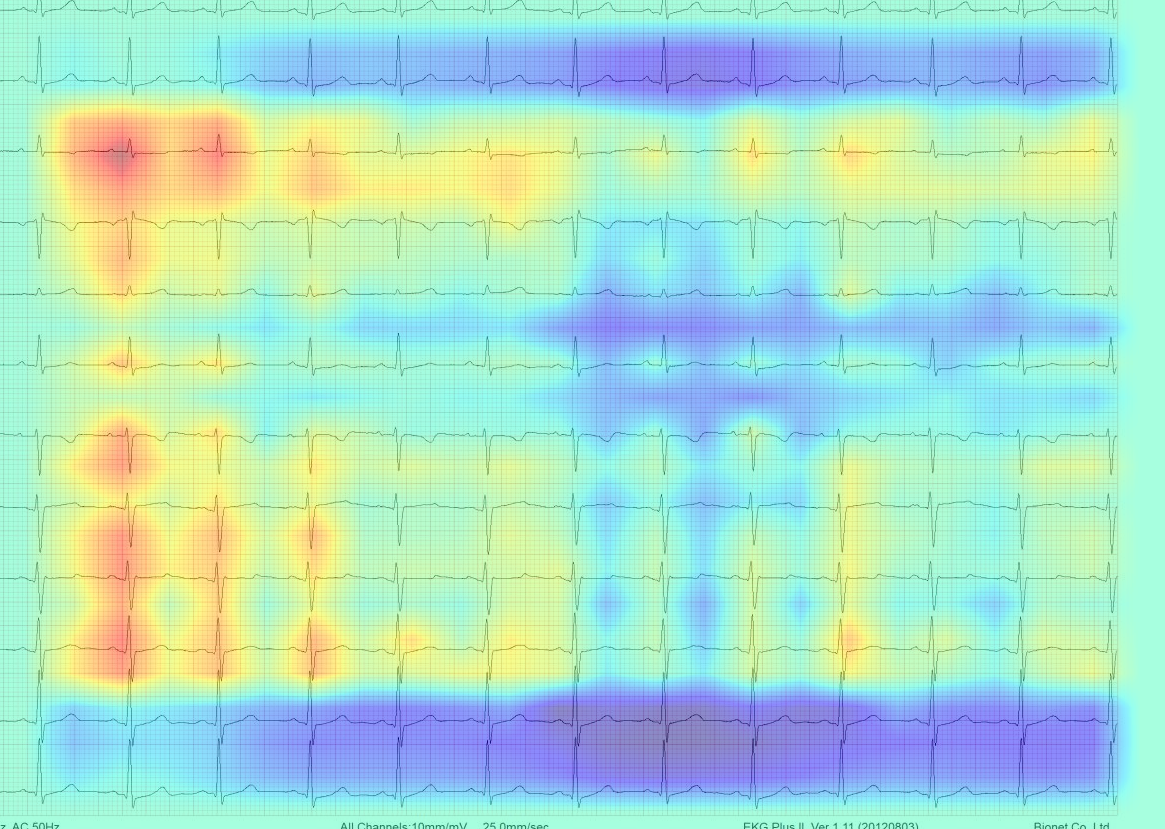

In [5]:

  model = CardioVLM().to(CFG.device)
  model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
  df = pd.read_csv(CFG.metadata_csv)
  explain_prediction(model, df.iloc[0], CFG.device)

In [6]:
"""
Attention hotspot comparison across diagnoses
==============================================
Checks whether CardioVLM's attention heatmap actually moves with the content
of the ECG, or whether it's camped on the same region regardless of input —
which is exactly what a positional/attention-sink bias would look like, and
is consistent with the earlier finding that RBBB vs Normal patients showed no
clean separation in peak attention lead.

Run this in a new cell AFTER the main training cell has executed (it reuses
CFG, CardioVLM, crop_rhythm_regions, crop_beat_regions, CONDITION_VOCAB, etc.
from that cell's global namespace — same convention as the existing
`explain_prediction` example cell).
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm

TARGET_CONDITIONS = [
    "Normal Sinus Rhythm",   # baseline: should show LOW/diffuse attention, no
                              # abnormality for the model to focus on
    "ICRBBB",
    "Inferior MI",
    "Sinus Bradycardia",
    "MI",
]


def _pick_patient(df, condition, label_cols, exclude_ids=None):
    """Pick a patient whose ONLY positive label (besides Normal Axis, which
    is common) is the target condition — avoids picking a multi-label patient
    where we can't tell which condition the attention is "for"."""
    exclude_ids = exclude_ids or set()
    col = f"label_{condition.replace(' ', '_')}"
    if col not in df.columns:
        return None
    other_cols = [c for c in label_cols if c != col and c != "label_Normal_Axis"]

    def _exclude(cands):
        if "patient_id" in df.columns:
            return cands[~cands["patient_id"].isin(exclude_ids)]
        return cands

    candidates = _exclude(df[(df[col] == 1) & (df[other_cols].sum(axis=1) == 0)])
    if len(candidates) == 0:
        # relax purity requirement, but NEVER drop the exclusion — reusing an
        # already-picked patient under a different condition label silently
        # produces a fake "different diagnosis" comparison that's actually
        # the same patient twice (this is exactly what happened with
        # Inferior MI / MI in the first version of this script)
        candidates = _exclude(df[df[col] == 1])
    if len(candidates) == 0:
        return None
    return candidates.iloc[0]


def _load_numeric_preprocessing():
    """Loads the exact same train-only median/mean/std values the deployed
    model was trained with, from the file main() saves them to. Used here
    (and should be used anywhere else a numeric tensor is built by hand
    outside of PairedECGDataset) so preprocessing can't silently drift out
    of sync with the model again -- that drift (a hardcoded 6-column list
    that never got updated to 9, and numeric values that were never
    normalized at all) is what caused the "1x6 and 9x128" shape-mismatch
    crash."""
    path = os.path.join(CFG.out_dir, "numeric_preprocessing.json")
    with open(path, "r") as f:
        preprocessing = json.load(f)
    train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
    numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
    numeric_stds = (pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32)
                     .replace(0, 1).fillna(1))
    return train_medians, numeric_means, numeric_stds


def _get_raw_heatmap(model, row, device, train_medians, numeric_means, numeric_stds):
    """Same core logic as explain_prediction, but returns the raw (pre-color)
    heatmap array and the source rhythm grid image, so we can compare
    hotspot location numerically across patients instead of eyeballing PNGs."""
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),   # matches training preprocessing (was
                                             # plain T.Resize before, distorting
                                             # the rhythm strip's aspect ratio)
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]

    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        _, attn_weights = model.encode(ecg_tensor, beat_tensor, numeric_tensor)

    patch_importance = attn_weights[0].mean(dim=0).cpu().numpy()
    grid_size = int(np.sqrt(len(patch_importance)))
    heatmap = patch_importance.reshape(grid_size, grid_size)
    heatmap[0, :] = heatmap[-1, :] = heatmap[:, 0] = heatmap[:, -1] = heatmap[1:-1, 1:-1].mean()
    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap_norm, rhythm_grid


def compare_attention_across_diagnoses(model, df, device, conditions=None,
                                          out_path="/kaggle/working/attention_comparison_grid.png"):
    conditions = conditions or TARGET_CONDITIONS
    label_cols = [c for c in df.columns if c.startswith("label_")]
    train_medians, numeric_means, numeric_stds = _load_numeric_preprocessing()

    results = []
    used_ids = set()
    for cond in conditions:
        row = _pick_patient(df, cond, label_cols, exclude_ids=used_ids)
        if row is None:
            print(f"  (skipping {cond}: no patient found in metadata)")
            continue
        if "patient_id" in df.columns:
            used_ids.add(row["patient_id"])

        heatmap, rhythm_grid = _get_raw_heatmap(model, row, device, train_medians, numeric_means, numeric_stds)

        # peak location and intensity-weighted centroid, both as fractions of
        # (height, width) so they're comparable across patients regardless of
        # image size
        peak_r, peak_c = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        yy, xx = np.mgrid[0:heatmap.shape[0], 0:heatmap.shape[1]]
        total = heatmap.sum()
        centroid_r = (yy * heatmap).sum() / total
        centroid_c = (xx * heatmap).sum() / total
        peak_frac = (peak_r / heatmap.shape[0], peak_c / heatmap.shape[1])
        centroid_frac = (centroid_r / heatmap.shape[0], centroid_c / heatmap.shape[1])
        # how concentrated the attention is: 1.0 = all mass on one patch,
        # near 0 = spread evenly. Low spread on every patient regardless of
        # diagnosis would itself be a red flag (nothing being "found").
        peak_value = float(heatmap[peak_r, peak_c])

        results.append({
            "condition": cond,
            "row": row,
            "heatmap": heatmap,
            "rhythm_grid": rhythm_grid,
            "peak_frac": peak_frac,
            "centroid_frac": centroid_frac,
            "peak_value": peak_value,
        })

    if len(results) < 2:
        print("Need at least 2 patients with different diagnoses to compare — "
              "check that these conditions exist in your metadata_csv.")
        return results

    # --- quantitative comparison table ---
    print(f"\n{'Condition':<22}{'Peak (row,col)':>18}{'Centroid (row,col)':>22}{'Peak value':>12}")
    print("-" * 76)
    for r in results:
        pr, pc = r["peak_frac"]
        cr, cc = r["centroid_frac"]
        print(f"{r['condition']:<22}{f'({pr:.2f}, {pc:.2f})':>18}"
              f"{f'({cr:.2f}, {cc:.2f})':>22}{r['peak_value']:>12.3f}")

    # spread of peak locations across all patients — if every patient's peak
    # lands within a small radius of each other regardless of diagnosis,
    # that's a positional bias, not content-driven attention
    peak_rows = np.array([r["peak_frac"][0] for r in results])
    peak_cols = np.array([r["peak_frac"][1] for r in results])
    spread_row = peak_rows.max() - peak_rows.min()
    spread_col = peak_cols.max() - peak_cols.min()
    print(f"\nPeak location spread across all patients: "
          f"row range={spread_row:.2f}, col range={spread_col:.2f} "
          f"(as fraction of image height/width)")
    if spread_row < 0.1 and spread_col < 0.1:
        print("-> Peaks are clustered in nearly the SAME spot regardless of diagnosis. "
              "This points to a positional/attention-sink bias, not content-driven "
              "explainability — treat the attention maps as unvalidated for now.")
    else:
        print("-> Peaks move meaningfully across patients — some content-driven signal.")

    # The peak is just the single strongest patch — it can move around even
    # if the bulk of attention mass is actually static. The centroid (the
    # intensity-weighted average over ALL patches) is the more honest check
    # for that: if it barely moves while the peak does, most of the model's
    # attention is sitting on a fixed baseline location regardless of
    # diagnosis, with only a small part actually tracking content.
    centroid_rows = np.array([r["centroid_frac"][0] for r in results])
    centroid_cols = np.array([r["centroid_frac"][1] for r in results])
    centroid_spread_row = centroid_rows.max() - centroid_rows.min()
    centroid_spread_col = centroid_cols.max() - centroid_cols.min()
    print(f"Centroid spread across all patients: "
          f"row range={centroid_spread_row:.2f}, col range={centroid_spread_col:.2f}")
    if centroid_spread_row < 0.1 and centroid_spread_col < 0.1:
        print("-> Centroid (the bulk of attention mass, not just the single peak) is "
              "essentially FROZEN across diagnoses, even where the peak moved. Most of "
              "the attention is sitting on a fixed baseline location regardless of "
              "input — report this as a real limitation, not just 'peaks moved so "
              "explainability works'. Peak movement alone overstates how content-driven "
              "the attention actually is.")
    else:
        print("-> Centroid also shifts meaningfully — stronger evidence of genuinely "
              "content-driven attention, not just a moving single peak on top of a "
              "static baseline.")

    # --- visual grid ---
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        heatmap_img = Image.fromarray((r["heatmap"] * 255).astype(np.uint8)).resize(
            r["rhythm_grid"].size, resample=Image.BILINEAR)
        heatmap_colored = (cm.jet(np.array(heatmap_img) / 255.0)[:, :, :3] * 255).astype(np.uint8)
        overlay = Image.blend(r["rhythm_grid"].convert("RGB"), Image.fromarray(heatmap_colored), alpha=0.45)
        ax.imshow(overlay)
        ax.set_title(r["condition"], fontsize=12)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\nSaved side-by-side comparison grid to {out_path}")

    return results


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   df = pd.read_csv(CFG.metadata_csv)
#   results = compare_attention_across_diagnoses(model, df, CFG.device)
#
# Prints a table of peak/centroid attention location per diagnosis (as
# fractions of image height/width, so comparable across patients) and saves
# a side-by-side heatmap grid. If every diagnosis's peak lands in nearly the
# same spot, that confirms a positional bias rather than genuine
# content-driven explainability.
# ---------------------------------------------------------------------------

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



Condition                 Peak (row,col)    Centroid (row,col)  Peak value
----------------------------------------------------------------------------
Normal Sinus Rhythm         (0.71, 0.67)          (0.46, 0.45)       0.999
ICRBBB                      (0.75, 0.83)          (0.47, 0.46)       1.000
Inferior MI                 (0.75, 0.17)          (0.49, 0.46)       0.999
Sinus Bradycardia           (0.79, 0.04)          (0.46, 0.44)       0.998
MI                          (0.50, 0.21)          (0.48, 0.47)       0.999

Peak location spread across all patients: row range=0.29, col range=0.79 (as fraction of image height/width)
-> Peaks move meaningfully across patients — some content-driven signal.
Centroid spread across all patients: row range=0.03, col range=0.03
-> Centroid (the bulk of attention mass, not just the single peak) is essentially FROZEN across diagnoses, even where the peak moved. Most of the attention is sitting on a fixed baseline location regardless of input — rep

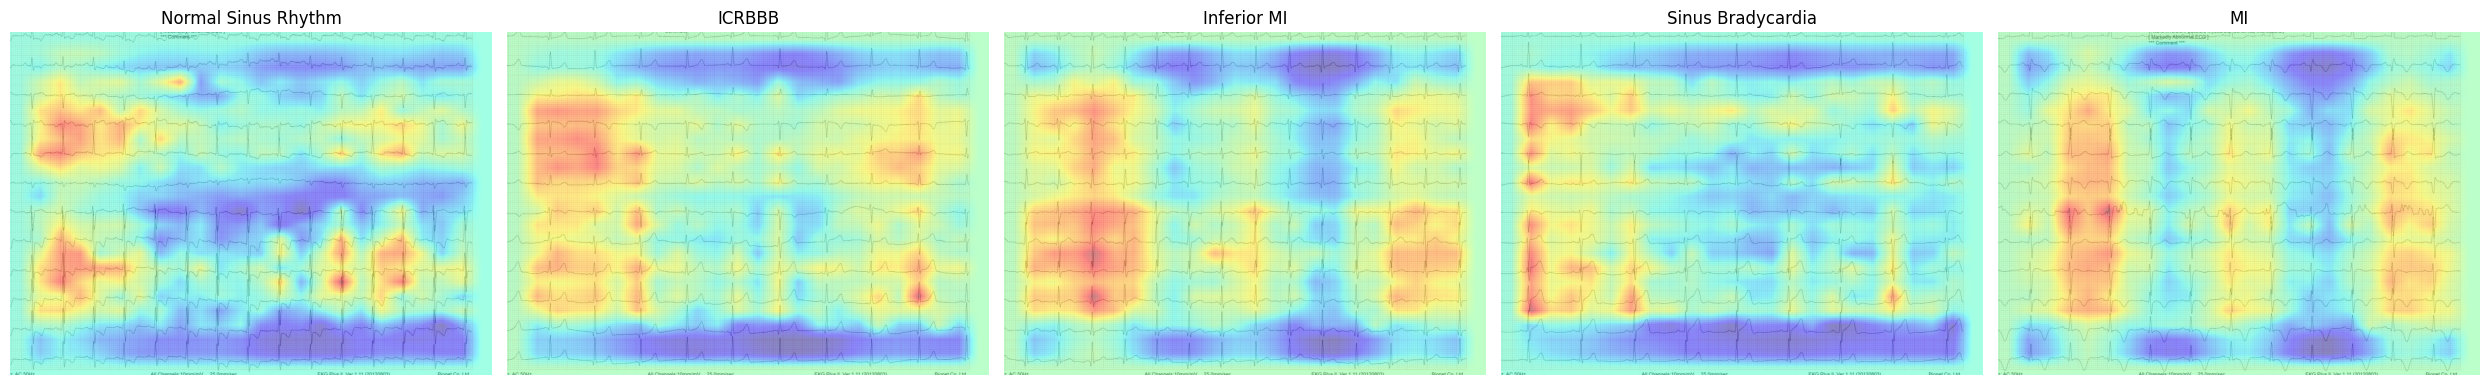


Saved side-by-side comparison grid to /kaggle/working/attention_comparison_grid.png


In [7]:
  model = CardioVLM().to(CFG.device)
  model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
  df = pd.read_csv(CFG.metadata_csv)
  results = compare_attention_across_diagnoses(model, df, CFG.device)

In [8]:
"""
Report generation quality evaluation
=====================================
Up to now the decoder's report output has only been eyeballed on single
samples ("Findings: Normal Axis." vs ground truth "Findings: Normal Sinus
Rhythm; Normal Axis; Normal ECG.") — this runs it systematically over the
whole TEST set (touched once, same set used for the final classification
numbers) and reports three things text quality metrics alone can't:

  1. Standard text-overlap metrics (BLEU-1/2, ROUGE-L) — how close the
     generated text is to the ground truth report, word-for-word.
  2. Condition-mention recall/precision — did the generated TEXT actually
     name the right conditions, regardless of exact wording? (a report that
     says "Findings: Sinus Bradycardia present" vs ground truth "Findings:
     Sinus Bradycardia" scores low on BLEU but should score perfectly here)
  3. Cross-head consistency — does the decoder's generated text agree with
     the classification head's own predictions on the SAME input? If the
     two heads disagree often, that's a real problem: it means the model
     doesn't have one coherent internal understanding of the ECG, it has two
     separate outputs that happen to share an encoder.

Run this in a new cell AFTER the main training cell (reuses CFG, CardioVLM,
CONDITION_VOCAB, PairedECGDataset, tokenizer, etc. already in the notebook).
"""

import json
import re
from collections import Counter


def extract_conditions_from_text(text, condition_vocab):
    """Same word-boundary matching parse_diagnosis uses on OCR'd text (fixes
    the earlier 'MI' substring-inside-'Minimally' bug) — applied here to the
    model's own generated/ground-truth report text instead of OCR output."""
    text_lower = text.lower()
    found = set()
    for cond in condition_vocab:
        if re.search(r"\b" + re.escape(cond.lower()) + r"\b", text_lower):
            found.add(cond)
    return found


def _ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def bleu_n(candidate, reference, n):
    """Simple single-reference BLEU-n with add-1 smoothing (add-1 avoids the
    0-if-any-n-gram-is-missing cliff that plain BLEU has on short clinical
    sentences, where a single wrong word would otherwise zero out the score)."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if len(cand_tokens) < n:
        return 0.0
    cand_ngrams = _ngrams(cand_tokens, n)
    ref_ngrams = _ngrams(ref_tokens, n)
    overlap = sum(min(c, ref_ngrams[g]) for g, c in cand_ngrams.items())
    total = sum(cand_ngrams.values())
    precision = (overlap + 1) / (total + 1)
    bp = 1.0 if len(cand_tokens) >= len(ref_tokens) else \
        np.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1))
    return bp * precision


def rouge_l(candidate, reference):
    """ROUGE-L: F-measure over the longest common subsequence of tokens —
    rewards preserving the right words in the right relative order even if
    phrasing differs, which matters more for clinical text than exact n-gram
    match."""
    cand_tokens = candidate.lower().split()
    ref_tokens = reference.lower().split()
    if not cand_tokens or not ref_tokens:
        return 0.0
    m, n = len(cand_tokens), len(ref_tokens)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if cand_tokens[i - 1] == ref_tokens[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    lcs = dp[m][n]
    if lcs == 0:
        return 0.0
    precision = lcs / m
    recall = lcs / n
    return 2 * precision * recall / (precision + recall)


def evaluate_report_quality(model, test_ds, device, condition_vocab, thresholds,
                              max_samples=None):
    model.eval()
    n = len(test_ds) if max_samples is None else min(max_samples, len(test_ds))

    bleu1_scores, bleu2_scores, rougeL_scores = [], [], []
    gen_vs_gt_tp = gen_vs_gt_fp = gen_vs_gt_fn = 0
    gen_vs_cls_agree = gen_vs_cls_total = 0
    examples = []

    with torch.no_grad():
        for i in range(n):
            sample = test_ds[i]
            ecg = sample["ecg_image"].unsqueeze(0).to(device)
            beat = sample["beat_image"].unsqueeze(0).to(device)
            numeric = sample["numeric"].unsqueeze(0).to(device)

            texts, _ = model.generate_report(ecg, beat, numeric)
            generated = texts[0]
            ground_truth = sample["report_text"]

            bleu1_scores.append(bleu_n(generated, ground_truth, 1))
            bleu2_scores.append(bleu_n(generated, ground_truth, 2))
            rougeL_scores.append(rouge_l(generated, ground_truth))

            gen_conds = extract_conditions_from_text(generated, condition_vocab)
            gt_conds = extract_conditions_from_text(ground_truth, condition_vocab)
            gen_vs_gt_tp += len(gen_conds & gt_conds)
            gen_vs_gt_fp += len(gen_conds - gt_conds)
            gen_vs_gt_fn += len(gt_conds - gen_conds)

            out = model(ecg, beat, numeric)
            probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
            cls_conds = {name for name, p in zip(condition_vocab, probs) if p > thresholds[name]}
            gen_vs_cls_agree += len(gen_conds & cls_conds) + len((set(condition_vocab) - gen_conds) - cls_conds)
            gen_vs_cls_total += len(condition_vocab)

            if i < 10:
                examples.append((generated, ground_truth, gen_conds, gt_conds, cls_conds))

    precision = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fp) if (gen_vs_gt_tp + gen_vs_gt_fp) > 0 else 0.0
    recall = gen_vs_gt_tp / (gen_vs_gt_tp + gen_vs_gt_fn) if (gen_vs_gt_tp + gen_vs_gt_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    cross_head_agreement = gen_vs_cls_agree / gen_vs_cls_total if gen_vs_cls_total > 0 else 0.0

    print(f"\n=== Report generation quality (TEST set, n={n}) ===")
    print(f"BLEU-1:  {np.mean(bleu1_scores):.3f}")
    print(f"BLEU-2:  {np.mean(bleu2_scores):.3f}")
    print(f"ROUGE-L: {np.mean(rougeL_scores):.3f}")
    print(f"\nCondition-mention (generated text vs ground-truth text, word-boundary matched):")
    print(f"  precision={precision:.3f}  recall={recall:.3f}  F1={f1:.3f}")
    print(f"\nCross-head agreement (generated text's conditions vs classification "
          f"head's own predictions, same input, per-condition agreement rate):")
    print(f"  {cross_head_agreement:.3f}")
    if cross_head_agreement < 0.85:
        print("  -> Below 0.85: the decoder and classifier disagree often enough that "
              "they don't appear to share one coherent understanding of the ECG. Worth "
              "flagging as a limitation — the two output heads may be learning "
              "somewhat independent shortcuts rather than a unified representation.")

    print(f"\n=== {min(10, n)} example generations ===")
    for gen, gt, gen_c, gt_c, cls_c in examples:
        print(f"  Generated: {gen}")
        print(f"  Ground truth: {gt}")
        print(f"  Text-conditions: {sorted(gen_c)} | Ground-truth-conditions: {sorted(gt_c)} "
              f"| Classifier-conditions: {sorted(cls_c)}")
        print()

    return {
        "bleu1": float(np.mean(bleu1_scores)),
        "bleu2": float(np.mean(bleu2_scores)),
        "rougeL": float(np.mean(rougeL_scores)),
        "condition_precision": precision,
        "condition_recall": recall,
        "condition_f1": f1,
        "cross_head_agreement": cross_head_agreement,
    }


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})   # dtype forced —
#   # otherwise pandas silently infers patient_id as int64 on reload (it's an
#   # all-digit string column), which won't match the strings saved in
#   # splits.json and test_df comes back empty (n=0) with no error
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#   test_ds = PairedECGDataset(test_df, tokenizer)
#
#   results = evaluate_report_quality(model, test_ds, CFG.device, CONDITION_VOCAB, thresholds)
#
# Uses the SAME test set as the final classification numbers (via splits.json)
# so this is a genuinely held-out check, not re-using train/val data.
# ---------------------------------------------------------------------------

In [9]:
 model = CardioVLM().to(CFG.device)
model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
with open(f"{CFG.out_dir}/label_config.json") as f:
    label_config = json.load(f)
thresholds = label_config["thresholds"]

with open(f"{CFG.out_dir}/splits.json") as f:
    splits = json.load(f)
with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
    preprocessing = json.load(f)
train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})   # dtype forced —
# otherwise pandas silently infers patient_id as int64 on reload (it's an
# all-digit string column), which won't match the strings saved in
# splits.json and test_df comes back empty (n=0) with no error
for col in train_medians.index:
    df[col] = df[col].fillna(train_medians[col])
df["axes_missing"] = df["axes_missing"].fillna(1.0)

test_df = df[df["patient_id"].isin(splits["test"])]
tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
test_ds = PairedECGDataset(test_df, tokenizer, numeric_means, numeric_stds)

results = evaluate_report_quality(model, test_ds, CFG.device, CONDITION_VOCAB, thresholds)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



=== Report generation quality (TEST set, n=378) ===
BLEU-1:  0.676
BLEU-2:  0.645
ROUGE-L: 0.744

Condition-mention (generated text vs ground-truth text, word-boundary matched):
  precision=0.896  recall=0.659  F1=0.760

Cross-head agreement (generated text's conditions vs classification head's own predictions, same input, per-condition agreement rate):
  0.925

=== 10 example generations ===
  Generated: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.
  Ground truth: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.
  Text-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm'] | Ground-truth-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm'] | Classifier-conditions: ['Normal Axis', 'Normal ECG', 'Normal Sinus Rhythm']

  Generated: Findings: Normal Axis; Sinus Tachycardia; Low Voltage.
  Ground truth: Findings: Normal Axis; Sinus Tachycardia.
  Text-conditions: ['Low Voltage', 'Normal Axis', 'Sinus Tachycardia'] | Ground-truth-conditions: ['Norma

In [10]:
"""
Human-readable report rendering
=================================
The decoder's generated text is terse and, as this project has repeatedly
shown, under-reports relative to what the classification head actually
knows about the same patient (cross-head agreement ~0.92, but the decoder
still misses conditions the classifier confidently caught -- see the
"Normal ECG" miss in the last report-quality run). Rather than trying to
make the decoder's own text more natural, this renders a human-readable
report FROM THE CLASSIFIER'S predictions instead -- the more complete and
reliable source -- and shows the decoder's generated text alongside only
as a secondary, informal reference.

Run this in a new cell after the main training cell (reuses CFG, CardioVLM,
CONDITION_VOCAB, PairedECGDataset, NUMERIC_COLS, etc. already in the
notebook).
"""

import json

# Natural-language phrasing for each condition. Kept clinically neutral —
# describes what was found, not a diagnosis/recommendation, since this is a
# research model's output, not a substitute for physician interpretation.
CONDITION_PHRASING = {
    "Normal Sinus Rhythm": "normal sinus rhythm",
    "Normal Axis": "a normal frontal-plane axis",
    "Normal ECG": "an otherwise normal ECG",
    "ICRBBB": "an incomplete right bundle branch block (ICRBBB)",
    "Atrial Fibrillation": "atrial fibrillation",
    "Sinus Bradycardia": "sinus bradycardia (a slower-than-normal heart rate)",
    "Sinus Tachycardia": "sinus tachycardia (a faster-than-normal heart rate)",
    "Left Axis Deviation": "left axis deviation",
    "Right Axis Deviation": "right axis deviation",
    "Inferior MI": "findings suggestive of an inferior myocardial infarction",
    "Anteroseptal MI": "findings suggestive of an anteroseptal myocardial infarction",
    "MI": "findings suggestive of a myocardial infarction",
    "ST abnormality": "an ST-segment abnormality",
    "Markedly Abnormal ECG": "a markedly abnormal overall ECG pattern",
    "LVH": "left ventricular hypertrophy (LVH)",
    "RVH": "right ventricular hypertrophy (RVH)",
    "PVC": "premature ventricular contractions (PVCs)",
    "Low Voltage": "low QRS voltage",
    "PAC": "premature atrial contractions (PACs)",
}

NORMAL_CONDITIONS = {"Normal Sinus Rhythm", "Normal Axis", "Normal ECG"}

# Conditions with fewer than this many total dataset examples get an
# explicit low-confidence caveat regardless of predicted probability, since
# this project's own calibration work showed these classes' thresholds
# aren't reliably tuned (see label_config.json's low_support_conditions).
LOW_SUPPORT_CAVEAT = "this is a rare finding in the training data and the model's confidence for it should be treated cautiously"


def render_human_readable_report(predicted_conditions, low_support_conditions=None):
    """
    predicted_conditions: list of (condition_name, confidence) tuples, e.g.
        the output already computed in main()'s "Sample inference" section:
        [('Normal Sinus Rhythm', 0.999), ('Normal Axis', 0.997), ...]
        (use the CLASSIFIER's thresholded predictions, not the decoder's
        generated text -- see module docstring for why)
    low_support_conditions: dict from label_config.json, e.g.
        {"Atrial Fibrillation": 14, "RVH": 12, ...}
    """
    low_support_conditions = low_support_conditions or {}
    names = [name for name, _ in predicted_conditions]
    normal_found = [n for n in names if n in NORMAL_CONDITIONS]
    abnormal_found = [(n, c) for n, c in predicted_conditions if n not in NORMAL_CONDITIONS]

    lines = []

    # --- opening line: normal findings, phrased as one sentence ---
    if normal_found and not abnormal_found:
        phrases = [CONDITION_PHRASING[n] for n in normal_found]
        if len(phrases) == 1:
            joined = phrases[0]
        elif len(phrases) == 2:
            joined = f"{phrases[0]} and {phrases[1]}"
        else:
            joined = ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
        lines.append(f"This ECG shows {joined}. No other abnormalities were detected.")
        lines.append("\nOverall impression: Normal ECG.")

    else:
        if normal_found:
            phrases = [CONDITION_PHRASING[n] for n in normal_found]
            joined = phrases[0] if len(phrases) == 1 else \
                ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
            lines.append(f"This ECG shows {joined}.")
        else:
            lines.append("This ECG does not show a clearly normal baseline rhythm/axis pattern.")

        # --- abnormal findings, one sentence each, confidence-qualified ---
        lines.append("\nAdditional findings:")
        for name, conf in abnormal_found:
            phrase = CONDITION_PHRASING.get(name, name)
            qualifier = "" if conf >= 0.7 else " (lower-confidence finding)"
            caveat = ""
            if name in low_support_conditions:
                caveat = f" Note: {LOW_SUPPORT_CAVEAT}."
            lines.append(f"  - {phrase[0].upper() + phrase[1:]}{qualifier} (model confidence: {conf:.0%}).{caveat}")

        lines.append("\nOverall impression: Abnormal ECG — see findings above.")

    lines.append(
        "\nThis report was generated by a research model (CardioVLM) and is "
        "not a substitute for physician interpretation. Clinical correlation "
        "is recommended."
    )
    return "\n".join(lines)


def render_report_for_patient(model, row, device, thresholds, condition_vocab,
                                 numeric_means, numeric_stds, train_medians,
                                 low_support_conditions=None, tokenizer=None,
                                 _print=True):
    """Runs the model on one patient row and renders both the human-readable
    (classifier-based) report and the decoder's own generated text side by
    side, so you can compare them directly."""
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(ecg_tensor, beat_tensor, numeric_tensor)
        probs = torch.sigmoid(out["logits"])[0].cpu().numpy()
    predicted = [(name, float(p)) for name, p in zip(condition_vocab, probs)
                 if p > thresholds[name]]

    human_report = render_human_readable_report(predicted, low_support_conditions)

    decoder_text = None
    if tokenizer is not None:
        texts, _ = model.generate_report(ecg_tensor, beat_tensor, numeric_tensor)
        decoder_text = texts[0]

    if _print:
        print("=" * 70)
        print("HUMAN-READABLE REPORT (from classifier predictions):")
        print("=" * 70)
        print(human_report)
        if decoder_text is not None:
            print("\n" + "-" * 70)
            print("Decoder's own generated text (secondary/informal reference):")
            print("-" * 70)
            print(decoder_text)
    return human_report, predicted, decoder_text


def render_reports_for_patients(model, test_df, device, thresholds, condition_vocab,
                                   numeric_means, numeric_stds, train_medians,
                                   low_support_conditions=None, tokenizer=None,
                                   n=10):
    """Batch version of render_report_for_patient — prints n patients in a
    row, each showing: ground truth, the human-readable (classifier-based)
    report, and the decoder's own generated text, clearly separated. Returns
    nothing (avoids the ugly Jupyter auto-display of a returned value/tuple
    that happens if a cell's last expression isn't assigned to a variable)."""
    for i in range(min(n, len(test_df))):
        row = test_df.iloc[i]
        human_report, predicted, decoder_text = render_report_for_patient(
            model, row, device, thresholds, condition_vocab,
            numeric_means, numeric_stds, train_medians,
            low_support_conditions=low_support_conditions, tokenizer=tokenizer,
            _print=False,
        )
        ground_truth = row["report_text"] if "report_text" in row and pd.notna(row["report_text"]) else "(unavailable)"

        print(f"\n{'#' * 70}")
        print(f"# Patient {i + 1}/{min(n, len(test_df))}")
        print(f"{'#' * 70}")
        print(f"\nGround truth: {ground_truth}")
        print(f"\n--- Human-readable report (from classifier) ---")
        print(human_report)
        if decoder_text is not None:
            print(f"\n--- Decoder's raw generated text (secondary reference) ---")
            print(decoder_text)
    return None



#
#   model = CardioVLM().to(CFG.device)
#   model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   # Single patient:
#   row = test_df.iloc[0]
#   _ = render_report_for_patient(model, row, CFG.device, thresholds, CONDITION_VOCAB,
#                                    numeric_means, numeric_stds, train_medians,
#                                    low_support_conditions=low_support, tokenizer=tokenizer)
#   # ^ the "_ = " matters in Jupyter -- without it, the cell's last expression
#   # (the function's return value) gets auto-displayed as a raw tuple/repr
#   # below your nicely printed report, which is what happened last time.
#
#   # Multiple patients at once (like the earlier 10-example report-quality run):
#   render_reports_for_patients(model, test_df, CFG.device, thresholds, CONDITION_VOCAB,
#                                  numeric_means, numeric_stds, train_medians,
#                                  low_support_conditions=low_support, tokenizer=tokenizer, n=10)
# ---------------------------------------------------------------------------

In [11]:
  model = CardioVLM().to(CFG.device)
  model.load_state_dict(torch.load(f"{CFG.out_dir}/cardiovlm_best.pt"))
  with open(f"{CFG.out_dir}/label_config.json") as f:
      label_config = json.load(f)
  thresholds = label_config["thresholds"]
  low_support = label_config.get("low_support_conditions", {})

  with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
      preprocessing = json.load(f)
  train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
  numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
  numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

  with open(f"{CFG.out_dir}/splits.json") as f:
      splits = json.load(f)
  df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
  test_df = df[df["patient_id"].isin(splits["test"])]
  tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

  # Single patient:
  row = test_df.iloc[0]
  _ = render_report_for_patient(model, row, CFG.device, thresholds, CONDITION_VOCAB,
                                   numeric_means, numeric_stds, train_medians,
                                   low_support_conditions=low_support, tokenizer=tokenizer)
  # ^ the "_ = " matters in Jupyter -- without it, the cell's last expression
  # (the function's return value) gets auto-displayed as a raw tuple/repr
  # below your nicely printed report, which is what happened last time.

  # Multiple patients at once (like the earlier 10-example report-quality run):
  render_reports_for_patients(model, test_df, CFG.device, thresholds, CONDITION_VOCAB,
                                 numeric_means, numeric_stds, train_medians,
                                 low_support_conditions=low_support, tokenizer=tokenizer, n=10)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


HUMAN-READABLE REPORT (from classifier predictions):
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG. No other abnormalities were detected.

Overall impression: Normal ECG.

This report was generated by a research model (CardioVLM) and is not a substitute for physician interpretation. Clinical correlation is recommended.

----------------------------------------------------------------------
Decoder's own generated text (secondary/informal reference):
----------------------------------------------------------------------
Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.

######################################################################
# Patient 1/10
######################################################################

Ground truth: Findings: Normal Sinus Rhythm; Normal Axis; Normal ECG.

--- Human-readable report (from classifier) ---
This ECG shows normal sinus rhythm, a normal frontal-plane axis, and an otherwise normal ECG. 

In [12]:
"""
Multi-seed evaluation
======================
Test macro_f1 has swung 0.271-0.438 across runs on the IDENTICAL train/val/
test split — meaning only the split was ever seeded, not model init or batch
order. A single run's number isn't trustworthy enough to report in a paper.

This holds the split fixed (reconstructed from splits.json, so it's the exact
same train/val/test patients every time) and varies ONLY the model init +
dataloader shuffling seed across several full training runs, so the resulting
spread isolates training-randomness instability specifically — not a mix of
"the split changed" and "the model changed", which is what was actually
varying across your last several runs.

Deliberately skips the expensive k-fold threshold calibration per seed —
evaluates all seeds at a fixed 0.5 threshold instead. Retuning thresholds per
seed would confound two different questions ("is the model stable" vs "is the
calibration stable"); this isolates the first one, which is what you asked.

Run this in a new cell AFTER the main training cell (reuses CFG, CardioVLM,
PairedECGDataset, CONDITION_VOCAB, train_one_epoch, evaluate, macro_f1_score,
etc. already in the notebook).

COST WARNING: this trains the full model from scratch once per seed (up to
CFG.epochs each, same as your main run). 3 seeds ~= 3x the time of one full
training run. Start with 3, not 5, unless you have time to spare.
"""

import copy
import random


def run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer, device,
                                 numeric_means, numeric_stds,
                                 seeds=(0, 1, 2), epochs=None,
                                 min_decoder_epochs=None, patience=4):
    # numeric_means/numeric_stds are now required (not optional) because
    # PairedECGDataset itself now requires them -- they must be TRAIN-ONLY
    # statistics (see the numeric-normalization leakage fix); load them from
    # {CFG.out_dir}/numeric_preprocessing.json rather than recomputing here,
    # so this uses the exact same stats the deployed model was trained with.
    # train_df/val_df/test_df must also already have their numeric columns
    # median-filled (PairedECGDataset no longer imputes internally) -- see
    # the usage example at the bottom of this file.
    epochs = epochs or CFG.epochs
    min_decoder_epochs = min_decoder_epochs or CFG.min_decoder_epochs

    train_ds = PairedECGDataset(train_df, tokenizer, numeric_means, numeric_stds)
    val_ds = PairedECGDataset(val_df, tokenizer, numeric_means, numeric_stds)
    test_ds = PairedECGDataset(test_df, tokenizer, numeric_means, numeric_stds)

    label_cols = [f"label_{c.replace(' ', '_')}" for c in CONDITION_VOCAB]
    pos_counts = train_df[label_cols].sum().values
    neg_counts = len(train_df) - pos_counts
    pos_weight = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 8.0)
    pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    results = []
    for seed in seeds:
        print(f"\n{'=' * 70}\n=== Seed {seed} ===\n{'=' * 70}")
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
        random.seed(seed)

        train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=2)

        model = CardioVLM().to(device)
        decoder_params = list(model.decoder.parameters())
        other_params = [p for n, p in model.named_parameters() if not n.startswith("decoder.")]
        optimizer = torch.optim.AdamW([
            {"params": other_params, "lr": CFG.lr},
            {"params": decoder_params, "lr": CFG.effective_decoder_lr},
        ])

        best_f1 = -1
        best_state = None
        epochs_since_improvement = 0

        for epoch in range(epochs):
            loss, cls_loss, report_loss = train_one_epoch(
                model, train_loader, optimizer, device, pos_weight=pos_weight)
            val_macro_f1 = macro_f1_score(model, val_loader, device, CONDITION_VOCAB)
            print(f"  seed {seed} epoch {epoch + 1}/{epochs} | loss={loss:.4f} "
                  f"report={report_loss:.4f} macro_f1={val_macro_f1:.3f}")

            if epoch + 1 < min_decoder_epochs:
                # same decoder-warmup floor as the main training loop — a
                # checkpoint frozen before this would risk the same
                # undertrained-decoder problem that showed up on the larger
                # dataset
                continue

            if val_macro_f1 > best_f1:
                best_f1 = val_macro_f1
                best_state = copy.deepcopy(model.state_dict())
                epochs_since_improvement = 0
            else:
                epochs_since_improvement += 1
                if epochs_since_improvement >= patience:
                    print(f"  seed {seed}: no improvement for {patience} epochs, "
                          f"stopping early at epoch {epoch + 1}.")
                    break

        model.load_state_dict(best_state)
        test_exact_match, test_per_label_acc = evaluate(model, test_loader, device)
        test_macro_f1 = macro_f1_score(model, test_loader, device, CONDITION_VOCAB)
        print(f"  seed {seed} FINAL (best val macro_f1={best_f1:.3f}) -> "
              f"test exact_match={test_exact_match:.3f} per_label_acc={test_per_label_acc:.3f} "
              f"test_macro_f1={test_macro_f1:.3f}")

        # Persist this seed's checkpoint -- previously discarded after scoring,
        # which meant the 3 independently-trained models couldn't be reused
        # for anything (like ensembling) afterward.
        seed_ckpt_path = os.path.join(CFG.out_dir, f"seed_{seed}_best.pt")
        torch.save(best_state, seed_ckpt_path)
        print(f"  seed {seed}: checkpoint saved to {seed_ckpt_path}")

        results.append({
            "seed": seed,
            "val_macro_f1": best_f1,
            "test_exact_match": test_exact_match,
            "test_per_label_acc": test_per_label_acc,
            "test_macro_f1": test_macro_f1,
            "checkpoint_path": seed_ckpt_path,
        })

        del model, best_state, optimizer
        torch.cuda.empty_cache()

    test_f1s = np.array([r["test_macro_f1"] for r in results])
    print(f"\n{'=' * 70}")
    print(f"=== Multi-seed summary ({len(seeds)} seeds, SAME train/val/test split, "
          f"only model init + batch order varied) ===")
    print(f"{'=' * 70}")
    for r in results:
        print(f"  seed {r['seed']}: test_macro_f1={r['test_macro_f1']:.3f}  "
              f"test_exact_match={r['test_exact_match']:.3f}  "
              f"test_per_label_acc={r['test_per_label_acc']:.3f}")

    std = test_f1s.std(ddof=1) if len(test_f1s) > 1 else 0.0
    print(f"\nTest macro_f1: mean={test_f1s.mean():.3f}  std={std:.3f}  "
          f"min={test_f1s.min():.3f}  max={test_f1s.max():.3f}")
    print(f"\nReport this as mean +/- std in the paper, not any single run's number — "
          f"the spread above is the honest measure of how reliable this model/dataset "
          f"combination actually is, not noise to average away.")

    return results


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell):
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   for col in train_medians.index:
#       df[col] = df[col].fillna(train_medians[col])
#   df["axes_missing"] = df["axes_missing"].fillna(1.0)
#
#   train_df = df[df["patient_id"].isin(splits["train"])]
#   val_df = df[df["patient_id"].isin(splits["val"])]
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer,
#                                          CFG.device, numeric_means, numeric_stds,
#                                          seeds=(0, 1, 2))
#
# COST WARNING: trains from scratch once per seed (up to CFG.epochs each).
# 3 seeds ~= 3x the time of one full training run — start with 3, not 5,
# unless you have time to spare.
# ---------------------------------------------------------------------------

In [13]:
  with open(f"{CFG.out_dir}/splits.json") as f:
      splits = json.load(f)
  with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
      preprocessing = json.load(f)
  train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
  numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
  numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

  df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
  for col in train_medians.index:
      df[col] = df[col].fillna(train_medians[col])
  df["axes_missing"] = df["axes_missing"].fillna(1.0)

  train_df = df[df["patient_id"].isin(splits["train"])]
  val_df = df[df["patient_id"].isin(splits["val"])]
  test_df = df[df["patient_id"].isin(splits["test"])]
  tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

  results = run_multi_seed_evaluation(train_df, val_df, test_df, tokenizer,
                                         CFG.device, numeric_means, numeric_stds,
                                         seeds=(0, 1, 2))


=== Seed 0 ===


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 0 epoch 1/15 | loss=1.3928 report=5.3117 macro_f1=0.213
  seed 0 epoch 2/15 | loss=0.5832 report=0.7893 macro_f1=0.319
  seed 0 epoch 3/15 | loss=0.4659 report=0.3398 macro_f1=0.403
  seed 0 epoch 4/15 | loss=0.4158 report=0.2271 macro_f1=0.413
  seed 0 epoch 5/15 | loss=0.3775 report=0.1854 macro_f1=0.387
  seed 0 epoch 6/15 | loss=0.3617 report=0.1527 macro_f1=0.413
  seed 0 epoch 7/15 | loss=0.3355 report=0.1408 macro_f1=0.413
  seed 0 epoch 8/15 | loss=0.3145 report=0.1294 macro_f1=0.367
  seed 0 epoch 9/15 | loss=0.2888 report=0.1193 macro_f1=0.425
  seed 0 epoch 10/15 | loss=0.2740 report=0.1107 macro_f1=0.456
  seed 0 epoch 11/15 | loss=0.2394 report=0.1062 macro_f1=0.464
  seed 0 epoch 12/15 | loss=0.2184 report=0.0946 macro_f1=0.472
  seed 0 epoch 13/15 | loss=0.2095 report=0.0907 macro_f1=0.464
  seed 0 epoch 14/15 | loss=0.1925 report=0.0877 macro_f1=0.468
  seed 0 epoch 15/15 | loss=0.1711 report=0.0813 macro_f1=0.459
  seed 0 FINAL (best val macro_f1=0.472) -> test 

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 1 epoch 1/15 | loss=1.3780 report=5.2549 macro_f1=0.283
  seed 1 epoch 2/15 | loss=0.5953 report=0.8326 macro_f1=0.274
  seed 1 epoch 3/15 | loss=0.4768 report=0.3616 macro_f1=0.364
  seed 1 epoch 4/15 | loss=0.4337 report=0.2402 macro_f1=0.360
  seed 1 epoch 5/15 | loss=0.4002 report=0.1938 macro_f1=0.436
  seed 1 epoch 6/15 | loss=0.3740 report=0.1629 macro_f1=0.425
  seed 1 epoch 7/15 | loss=0.3438 report=0.1411 macro_f1=0.382
  seed 1 epoch 8/15 | loss=0.3211 report=0.1296 macro_f1=0.410
  seed 1 epoch 9/15 | loss=0.3003 report=0.1221 macro_f1=0.430
  seed 1 epoch 10/15 | loss=0.2803 report=0.1164 macro_f1=0.388
  seed 1 epoch 11/15 | loss=0.2588 report=0.1039 macro_f1=0.400
  seed 1 epoch 12/15 | loss=0.2333 report=0.1086 macro_f1=0.446
  seed 1 epoch 13/15 | loss=0.2186 report=0.0925 macro_f1=0.401
  seed 1 epoch 14/15 | loss=0.2049 report=0.0957 macro_f1=0.366
  seed 1 epoch 15/15 | loss=0.1829 report=0.0879 macro_f1=0.363
  seed 1 FINAL (best val macro_f1=0.446) -> test 

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  seed 2 epoch 1/15 | loss=1.4462 report=5.6862 macro_f1=0.141
  seed 2 epoch 2/15 | loss=0.6236 report=0.8421 macro_f1=0.280
  seed 2 epoch 3/15 | loss=0.5010 report=0.3503 macro_f1=0.298
  seed 2 epoch 4/15 | loss=0.4536 report=0.2309 macro_f1=0.356
  seed 2 epoch 5/15 | loss=0.4231 report=0.1794 macro_f1=0.384
  seed 2 epoch 6/15 | loss=0.3899 report=0.1584 macro_f1=0.388
  seed 2 epoch 7/15 | loss=0.3725 report=0.1474 macro_f1=0.393
  seed 2 epoch 8/15 | loss=0.3484 report=0.1344 macro_f1=0.400
  seed 2 epoch 9/15 | loss=0.3280 report=0.1219 macro_f1=0.391
  seed 2 epoch 10/15 | loss=0.3014 report=0.1110 macro_f1=0.447
  seed 2 epoch 11/15 | loss=0.2789 report=0.1077 macro_f1=0.443
  seed 2 epoch 12/15 | loss=0.2536 report=0.1000 macro_f1=0.479
  seed 2 epoch 13/15 | loss=0.2434 report=0.0948 macro_f1=0.427
  seed 2 epoch 14/15 | loss=0.2190 report=0.0948 macro_f1=0.385
  seed 2 epoch 15/15 | loss=0.2080 report=0.0881 macro_f1=0.444
  seed 2 FINAL (best val macro_f1=0.479) -> test 

In [14]:
"""
Ensemble + tiered-confidence report generation
=================================================
Two changes over the single-model report generator, aimed specifically at
reducing missed findings (e.g. the Low Voltage miss on Patient 4, the LVH
miss on Patient 8 in the last batch of 10):

  1. ENSEMBLE ACROSS SEEDS. This project's own multi-seed check showed a
     single checkpoint's predictions are noisier than they look -- test
     macro_f1 swung 0.271-0.484 across otherwise-identical runs. Averaging
     sigmoid probabilities across multiple independently-trained models
     (the seed_N_best.pt checkpoints, now saved by the updated multi-seed
     script) gives steadier, usually more accurate per-patient predictions
     than any single model -- this is the standard reason ensembling helps,
     and directly targets exactly this kind of single-model miss.

  2. A SECOND, LOWER "POSSIBLE FINDING" TIER. The formal classification
     threshold was tuned to optimize F1 for the classification metric, not
     for what a report reader wants. For a report, a missed real finding is
     worse than a flagged uncertain one. Anything scoring between a lower
     "possible" cutoff and the formal threshold is now shown in a separate,
     clearly-labeled section instead of being silently invisible.

Run this in a new cell after the main training cell AND after the (updated)
multi-seed evaluation cell has run at least once with checkpoint saving
enabled (produces {CFG.out_dir}/seed_0_best.pt, seed_1_best.pt, ...).
"""

import glob
import copy

# Reuses CONDITION_PHRASING, NORMAL_CONDITIONS, LOW_SUPPORT_CAVEAT already
# defined in the notebook's global namespace -- run the human_readable_report
# (v2) cell BEFORE this one, in the same notebook session.


def load_ensemble_models(device, ckpt_glob=None):
    """Loads every seed_*_best.pt checkpoint found, plus the main
    cardiovlm_best.pt if present, as a list of ready-to-eval models."""
    ckpt_glob = ckpt_glob or os.path.join(CFG.out_dir, "seed_*_best.pt")
    paths = sorted(glob.glob(ckpt_glob))
    main_ckpt = os.path.join(CFG.out_dir, "cardiovlm_best.pt")
    if os.path.exists(main_ckpt) and main_ckpt not in paths:
        paths.append(main_ckpt)
    if not paths:
        raise FileNotFoundError(
            f"No checkpoints found matching {ckpt_glob} (and no {main_ckpt}). "
            "Run the multi-seed evaluation cell first -- it now saves each "
            "seed's checkpoint instead of discarding it.")
    models = []
    for p in paths:
        m = CardioVLM().to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval()
        models.append(m)
    print(f"Loaded {len(models)} model(s) for ensembling: {[os.path.basename(p) for p in paths]}")
    return models


def ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor):
    """Averages sigmoid probabilities across all models -- averaging
    probabilities (not logits) is the more standard and robust choice for
    an ensemble of classifiers with potentially different calibration."""
    all_probs = []
    with torch.no_grad():
        for m in models:
            out = m(ecg_tensor, beat_tensor, numeric_tensor)
            all_probs.append(torch.sigmoid(out["logits"]))
    return torch.stack(all_probs, dim=0).mean(dim=0)[0].cpu().numpy()


def render_tiered_report(high_confidence, possible, low_support_conditions=None):
    """Like render_human_readable_report, but with an added 'possible
    finding' section for anything between the possible-cutoff and the
    formal threshold -- surfaced instead of silently hidden, since a report
    reader is better served by an uncertain mention than a silent miss."""
    low_support_conditions = low_support_conditions or {}
    names = [name for name, _ in high_confidence]
    normal_found = [n for n in names if n in NORMAL_CONDITIONS]
    abnormal_found = [(n, c) for n, c in high_confidence if n not in NORMAL_CONDITIONS]

    lines = []
    if normal_found and not abnormal_found:
        phrases = [CONDITION_PHRASING[n] for n in normal_found]
        joined = phrases[0] if len(phrases) == 1 else \
            (f"{phrases[0]} and {phrases[1]}" if len(phrases) == 2 else
             ", ".join(phrases[:-1]) + f", and {phrases[-1]}")
        lines.append(f"This ECG shows {joined}. No other high-confidence abnormalities were detected.")
        lines.append("\nOverall impression: Normal ECG.")
    else:
        if normal_found:
            phrases = [CONDITION_PHRASING[n] for n in normal_found]
            joined = phrases[0] if len(phrases) == 1 else \
                ", ".join(phrases[:-1]) + f", and {phrases[-1]}"
            lines.append(f"This ECG shows {joined}.")
        else:
            lines.append("This ECG does not show a clearly normal baseline rhythm/axis pattern.")

        lines.append("\nFindings:")
        for name, conf in abnormal_found:
            phrase = CONDITION_PHRASING.get(name, name)
            caveat = f" Note: {LOW_SUPPORT_CAVEAT}." if name in low_support_conditions else ""
            lines.append(f"  - {phrase[0].upper() + phrase[1:]} (model confidence: {conf:.0%}).{caveat}")
        lines.append("\nOverall impression: Abnormal ECG — see findings above.")

    if possible:
        lines.append(
            "\nPossible additional findings (below the model's standard confidence "
            "threshold — mentioned for completeness, not confirmed):"
        )
        for name, conf in possible:
            phrase = CONDITION_PHRASING.get(name, name)
            lines.append(f"  - Possible {phrase} (model confidence: {conf:.0%}).")

    lines.append(
        "\nThis report was generated by a research model (CardioVLM, ensemble of "
        f"multiple models) and is not a substitute for physician interpretation. "
        "Clinical correlation is recommended."
    )
    return "\n".join(lines)


def render_ensemble_report_for_patient(models, row, device, thresholds, condition_vocab,
                                          numeric_means, numeric_stds, train_medians,
                                          low_support_conditions=None, possible_margin=0.20,
                                          tokenizer=None, _print=True):
    """possible_margin: how far below each condition's formal threshold counts
    as a 'possible finding' (default 0.20 -- e.g. a threshold of 0.55 means
    anything scoring 0.35-0.55 shows up as 'possible' instead of invisible)."""
    transform = T.Compose([
        ResizeWithPadding(CFG.img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    rhythm_grid = crop_rhythm_regions(row["rhythm_path"])["grid"]
    beat_grid = crop_beat_regions(row["beat_path"])["grid"]
    ecg_tensor = transform(rhythm_grid).unsqueeze(0).to(device)
    beat_tensor = transform(beat_grid).unsqueeze(0).to(device)

    numeric_values = pd.Series(
        {col: row[col] if col in row.index else np.nan for col in NUMERIC_COLS},
        dtype=np.float32)
    for col in train_medians.index:
        if pd.isna(numeric_values[col]):
            numeric_values[col] = train_medians[col]
    if pd.isna(numeric_values["axes_missing"]):
        numeric_values["axes_missing"] = 1.0
    numeric_norm = (numeric_values.values - numeric_means.values) / numeric_stds.values
    numeric_tensor = torch.tensor(numeric_norm, dtype=torch.float32).unsqueeze(0).to(device)

    probs = ensemble_predict_probs(models, ecg_tensor, beat_tensor, numeric_tensor)

    high_confidence, possible = [], []
    for name, p in zip(condition_vocab, probs):
        t = thresholds[name]
        if p > t:
            high_confidence.append((name, float(p)))
        elif p > max(t - possible_margin, 0.0):
            possible.append((name, float(p)))

    report = render_tiered_report(high_confidence, possible, low_support_conditions)

    decoder_text = None
    if tokenizer is not None:
        # decoder text from the first ensemble member only (generation isn't
        # meaningfully ensemble-able the way classification logits are)
        texts, _ = models[0].generate_report(ecg_tensor, beat_tensor, numeric_tensor)
        decoder_text = texts[0]

    if _print:
        print("=" * 70)
        print(f"ENSEMBLE REPORT ({len(models)} models):")
        print("=" * 70)
        print(report)
        if decoder_text is not None:
            print("\n" + "-" * 70)
            print("Decoder's own generated text (secondary/informal reference):")
            print("-" * 70)
            print(decoder_text)
    return report, high_confidence, possible, decoder_text


# ---------------------------------------------------------------------------
# Example usage (run in a new cell after the main training cell, and after
# the multi-seed evaluation cell has produced seed_0_best.pt etc.):
#
#   models = load_ensemble_models(CFG.device)
#
#   with open(f"{CFG.out_dir}/label_config.json") as f:
#       label_config = json.load(f)
#   thresholds = label_config["thresholds"]
#   low_support = label_config.get("low_support_conditions", {})
#
#   with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
#       preprocessing = json.load(f)
#   train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
#   numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
#   numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)
#
#   with open(f"{CFG.out_dir}/splits.json") as f:
#       splits = json.load(f)
#   df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
#   test_df = df[df["patient_id"].isin(splits["test"])]
#   tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)
#
#   row = test_df.iloc[3]   # e.g. the Low Voltage patient that got missed
#   _ = render_ensemble_report_for_patient(models, row, CFG.device, thresholds,
#                                             CONDITION_VOCAB, numeric_means, numeric_stds,
#                                             train_medians, low_support_conditions=low_support,
#                                             tokenizer=tokenizer)
# ---------------------------------------------------------------------------

In [15]:
  models = load_ensemble_models(CFG.device)

  with open(f"{CFG.out_dir}/label_config.json") as f:
      label_config = json.load(f)
  thresholds = label_config["thresholds"]
  low_support = label_config.get("low_support_conditions", {})

  with open(f"{CFG.out_dir}/numeric_preprocessing.json") as f:
      preprocessing = json.load(f)
  train_medians = pd.Series(preprocessing["train_medians"], dtype=np.float32)
  numeric_means = pd.Series(preprocessing["numeric_means"], index=NUMERIC_COLS, dtype=np.float32)
  numeric_stds = pd.Series(preprocessing["numeric_stds"], index=NUMERIC_COLS, dtype=np.float32).replace(0, 1).fillna(1)

  with open(f"{CFG.out_dir}/splits.json") as f:
      splits = json.load(f)
  df = pd.read_csv(CFG.metadata_csv, dtype={"patient_id": str})
  test_df = df[df["patient_id"].isin(splits["test"])]
  tokenizer = AutoTokenizer.from_pretrained(CFG.decoder_name)

  row = test_df.iloc[3]   # e.g. the Low Voltage patient that got missed
  _ = render_ensemble_report_for_patient(models, row, CFG.device, thresholds,
                                            CONDITION_VOCAB, numeric_means, numeric_stds,
                                            train_medians, low_support_conditions=low_support,
                                            tokenizer=tokenizer)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded 4 model(s) for ensembling: ['seed_0_best.pt', 'seed_1_best.pt', 'seed_2_best.pt', 'cardiovlm_best.pt']
ENSEMBLE REPORT (4 models):
This ECG shows normal sinus rhythm, and a normal frontal-plane axis.

Findings:
  - Findings suggestive of a myocardial infarction (model confidence: 68%).
  - A markedly abnormal overall ECG pattern (model confidence: 36%).

Overall impression: Abnormal ECG — see findings above.

Possible additional findings (below the model's standard confidence threshold — mentioned for completeness, not confirmed):
  - Possible an otherwise normal ECG (model confidence: 25%).
  - Possible findings suggestive of an inferior myocardial infarction (model confidence: 22%).
  - Possible premature atrial contractions (PACs) (model confidence: 20%).

This report was generated by a research model (CardioVLM, ensemble of multiple models) and is not a substitute for physician interpretation. Clinical correlation is recommended.

--------------------------------------------